# Notebook 03 — Validation (GFM extent) + Population Exposure Dashboard

This notebook validates **modelled flood extent** (from Notebooks 1 & 2) against **GFM observed flood extent** for your basin or municipalities.

**Pipeline**: discharge → return period (EVT/POT) → JRC depth maps (CLIMADA-Petals) → modelled extent → **validation metrics**

**Outputs**:
- **CSV metrics**: Confusion matrix (TP/FP/FN/TN), F1, IoU, Precision, Recall, Bias at multiple depth thresholds
- **Population exposure tables**: Affected population by municipality (modelled vs. observed)
- **Interactive HTML dashboard**: Leaflet map + Plotly charts with event selector, scenario toggle, depth slider

**Design principle**: Validates binary flood extent (presence/absence), not depth accuracy. Population is an **impact proxy** only.

**Prerequisites**:
- ✅ Notebook 1 calibration complete (EVT parameters)
- ✅ Notebook 2 hazard integration complete (flood depth maps)
- ✅ GFM observed extent data available (GeoTIFF files with dates)

**Duration**: ~30-60 minutes per flood episode

**Documentation**: See [Notebook 3 Validation Guide](../../docs/user-guides/notebook03-validation-guide.md) for detailed walkthrough.


## 0) Environment & imports


In [1]:
from __future__ import annotations

import os
import re
import json
import math
import base64
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List, Tuple, Optional

import numpy as np
import pandas as pd

import geopandas as gpd
import xarray as xr

from shapely.geometry import box

import rasterio
from rasterio.merge import merge as rio_merge
from rasterio.mask import mask as rio_mask
from rasterio.warp import reproject, Resampling
from rasterio.enums import Resampling as RioResampling

import matplotlib.pyplot as plt

# Notebook display helper
try:
    from IPython.display import display
except Exception:
    def display(x):
        print(x)
    print("IPythom not available, install it")


# Optional: faster zonal stats if available
try:
    from rasterstats import zonal_stats
    RASTERSTATS_AVAILABLE = True
except Exception:
    RASTERSTATS_AVAILABLE = False
    print("rasterstats not available, install it")

# --- CLIMADA / PETALS ---
CLIMADA_AVAILABLE = True
try:
    from climada_petals.hazard.rf_glofas.transform_ops import (
        regrid as petals_regrid,
        flood_depth as petals_flood_depth,
        apply_flopros as petals_apply_flopros,
    )
    from climada_petals.hazard.rf_glofas.setup import download_flopros_database
except Exception as e:
    CLIMADA_AVAILABLE = False
    print("❌ CLIMADA-Petals import failed:", e)
    print("   This notebook requires CLIMADA-Petals for regrid + flood_depth + FLOPROS masking.")
    print("   Fix your environment, then restart the kernel.")

# --- Project helper (EVT POT discharge -> RP) ---
try:
    from philflood.calibration.evt_pot import discharge_to_return_period_pot  # preferred if running inside repo env
except Exception:
    # fallback: import local file if notebook is run outside installed package
    try:
        from philflood.calibration.evt_pot import discharge_to_return_period_pot
    except Exception as e:
        raise ImportError("Could not import discharge_to_return_period_pot from philflood.calibration.evt_pot or evt_pot.py") from e

print("✅ Imports complete.")


✅ Imports complete.


## 0.5) Pre-flight check (fast fail + actionable diagnostics)

Run this cell once. If it fails, fix before continuing.

**Checks performed**:
- ✅ All required Python packages installed (numpy, pandas, geopandas, rasterio, xarray, CLIMADA-Petals)
- ✅ Data files exist (HYBAS, ADM3, WorldPop, GFM directory)
- ✅ Output directory is writable

**Troubleshooting**: See [Notebook 03 Issues](../../docs/user-guides/troubleshooting.md#notebook-03-validation-issues)


## 1) Robust paths (repo-root detection + defaults)


In [2]:

REPO_ROOT_MANUAL = None  # e.g., Path(r"C:\pipelines\GLOFAS_ImpactFloodForecasting_PHL")

def find_repo_root(start: Optional[Path] = None) -> Path:
    markers = ["pyproject.toml", "setup.cfg", "setup.py", ".git", "src"]
    p = (start or Path.cwd()).resolve()
    if p.is_file():
        p = p.parent
    for parent in (p, *p.parents):
        if any((parent / m).exists() for m in markers):
            return parent
    raise RuntimeError("Could not find repo root automatically. Set REPO_ROOT_MANUAL.")

if REPO_ROOT_MANUAL is None:
    try:
        REPO_ROOT = find_repo_root()
    except Exception:
        REPO_ROOT = Path(r"C:\pipelines\GLOFAS_ImpactFloodForecasting_PHL")
else:
    REPO_ROOT = Path(REPO_ROOT_MANUAL)

REPO_ROOT = REPO_ROOT.resolve()
print("REPO_ROOT =", REPO_ROOT)

DATA_RAW = REPO_ROOT / "data" / "raw"
DATA_PROCESSED = REPO_ROOT / "data" / "processed"
DATA_INTERIM = REPO_ROOT / "data" / "interim"

# User-provided key paths (defaults)
HYBAS_L7_SHP = Path(r"C:\pipelines\GLOFAS_ImpactFloodForecasting_PHL\data\raw\vectors\hydrobasins\australasia\hybas_au_lev01-12_v1c\hybas_au_lev07_v1c.shp")
ADM3_GEOJSON = Path(r"C:\pipelines\GLOFAS_ImpactFloodForecasting_PHL\data\raw\vectors\admin\phl_cod_ab\phl_adm3.geojson")
WORLDPOP_RASTER = Path(r"C:\pipelines\GLOFAS_ImpactFloodForecasting_PHL\data\raw\worldpop\PHL\phl_pop_2025_CN_100m_R2025A_v1.tif")
GFM_VALIDATION_ROOT = Path(r"C:\pipelines\GLOFAS_ImpactFloodForecasting_PHL\data\interim\validation\GFM\Cagayan")


JRC_RAW_ROOT = Path(r"C:\pipelines\GLOFAS_ImpactFloodForecasting_PHL\data\raw\jrc_flood_maps")

# Output root for this notebook
VALIDATION_OUT_ROOT = DATA_PROCESSED / "validation"
OUT_DIR = VALIDATION_OUT_ROOT  # Main output directory for validation results
print("Defaults set.")

REPO_ROOT = C:\pipelines\GLOFAS_ImpactFloodForecasting_PHL
Defaults set.


In [3]:
import sys, platform
import importlib.metadata as im

def _pkg_version(name: str) -> str:
    try:
        return im.version(name)
    except Exception:
        return "not-installed"

print("🧪 Pre-flight check")
print("Python:", sys.version.split()[0], "|", platform.platform())
print("Repo root:", REPO_ROOT)

required = [
    ("numpy","numpy"),
    ("pandas","pandas"),
    ("geopandas","geopandas"),
    ("rasterio","rasterio"),
    ("xarray","xarray"),
    ("pyarrow","pyarrow"),
    ("requests","requests"),
    ("Pillow","Pillow"),
]
print("\n📦 Packages:")
for label, pkg in required:
    print(f"  - {label:10s}: {_pkg_version(pkg)}")

if not CLIMADA_AVAILABLE:
    raise RuntimeError("CLIMADA-Petals is required but not importable. Activate the correct environment and restart the kernel.")

def _assert_exists(p: Path, label: str):
    if not Path(p).exists():
        raise FileNotFoundError(f"Missing {label}: {p}")
    print(f"  ✅ {label}: {p}")

print("\n📁 Required inputs:")
_assert_exists(HYBAS_L7_SHP, "HYBAS_L7_SHP")
_assert_exists(ADM3_GEOJSON, "ADM3_GEOJSON")
_assert_exists(WORLDPOP_RASTER, "WORLDPOP_RASTER")
_assert_exists(GFM_VALIDATION_ROOT, "GFM_VALIDATION_ROOT")
_assert_exists(JRC_RAW_ROOT, "JRC_RAW_ROOT")

OUT_DIR.mkdir(parents=True, exist_ok=True)
tmp = OUT_DIR / "_preflight_write_test.txt"
tmp.write_text("ok", encoding="utf-8")
tmp.unlink(missing_ok=True)
print("\n✅ Output directory writable:", OUT_DIR)

print("\n✅ Pre-flight passed (basic).")

🧪 Pre-flight check
Python: 3.11.14 | Windows-10-10.0.26100-SP0
Repo root: C:\pipelines\GLOFAS_ImpactFloodForecasting_PHL

📦 Packages:
  - numpy     : 1.26.4
  - pandas    : 2.1.4
  - geopandas : 0.14.4
  - rasterio  : 1.4.3
  - xarray    : 2025.1.2
  - pyarrow   : 20.0.0
  - requests  : 2.32.5
  - Pillow    : 10.4.0

📁 Required inputs:
  ✅ HYBAS_L7_SHP: C:\pipelines\GLOFAS_ImpactFloodForecasting_PHL\data\raw\vectors\hydrobasins\australasia\hybas_au_lev01-12_v1c\hybas_au_lev07_v1c.shp
  ✅ ADM3_GEOJSON: C:\pipelines\GLOFAS_ImpactFloodForecasting_PHL\data\raw\vectors\admin\phl_cod_ab\phl_adm3.geojson
  ✅ WORLDPOP_RASTER: C:\pipelines\GLOFAS_ImpactFloodForecasting_PHL\data\raw\worldpop\PHL\phl_pop_2025_CN_100m_R2025A_v1.tif
  ✅ GFM_VALIDATION_ROOT: C:\pipelines\GLOFAS_ImpactFloodForecasting_PHL\data\interim\validation\GFM\Cagayan
  ✅ JRC_RAW_ROOT: C:\pipelines\GLOFAS_ImpactFloodForecasting_PHL\data\raw\jrc_flood_maps

✅ Output directory writable: C:\pipelines\GLOFAS_ImpactFloodForecasting_

## 2) Auto-detect calibration run (like Notebook 02)

Automatically finds and loads your latest Notebook 1 calibration output.

**Loaded**:
- Basin ID or municipality selection
- EVT parameters (parquet file path)
- Discharge timeseries directory
- Selection mode (basin vs. municipality)

**To manually specify**: Set `AUTO_DETECT = False` and provide `BASIN_ID_HINT` and `RUN_TAG_HINT`.

In [4]:
AUTO_DETECT = True
BASIN_ID_HINT = None   # e.g. "Cagayan_01"
RUN_TAG_HINT = None    # e.g. "2026-01-19_calib-test"

def find_latest_run_config(processed_root: Path, basin_id_hint: Optional[str]=None, run_tag_hint: Optional[str]=None) -> Path:
    calib_root = processed_root / "calibration" / "evt_pot"
    if basin_id_hint and run_tag_hint:
        p = calib_root / basin_id_hint / run_tag_hint / "run_config.json"
        if not p.exists():
            raise FileNotFoundError(f"run_config.json not found at {p}")
        return p

    candidates = list(calib_root.glob("*/*/run_config.json"))
    if basin_id_hint:
        candidates = [c for c in candidates if c.parent.parent.name == basin_id_hint]
    if not candidates:
        raise FileNotFoundError(f"No run_config.json found under: {calib_root}")
    candidates.sort(key=lambda p: p.stat().st_mtime, reverse=True)
    return candidates[0]

if AUTO_DETECT:
    run_config_path = find_latest_run_config(DATA_PROCESSED, BASIN_ID_HINT, RUN_TAG_HINT)
    run_config = json.loads(run_config_path.read_text(encoding="utf-8"))
    selection_mode = run_config.get("selection_mode", "basin")
    USE_MUNI_AOI = bool(run_config.get("use_muni_aoi", selection_mode == "municipality"))
    BASIN_ID = run_config.get("basin_id", "MUNI_SELECTION")
    RUN_TAG = run_config.get("run_tag")
    
    # Retrocompatibility: support both old (adm3_names) and new (adm3_ids) formats
    if "adm3_ids" in run_config:
        SELECTED_MUNIS = run_config["adm3_ids"]  # New format: list of IDs
    elif "selected_municipalities" in run_config:
        # Old format: could be list of names or count
        sm = run_config["selected_municipalities"]
        SELECTED_MUNIS = sm if isinstance(sm, list) else []
    else:
        SELECTED_MUNIS = []
    
    print("✅ Auto-detected run config:", run_config_path)
    print(json.dumps(run_config, indent=2))
else:
    USE_MUNI_AOI = True
    BASIN_ID = BASIN_ID_HINT or "MUNI_SELECTION"
    RUN_TAG = RUN_TAG_HINT or "2026-01-19_calib-test"
    SELECTED_MUNIS = []
    print("⚠️ Manual configuration in use.")


EVT_PARAMS_PARQUET = DATA_PROCESSED / "calibration" / "evt_pot" / BASIN_ID / RUN_TAG / "results" / "evt_pot_calibration.parquet"
TIMESERIES_DIR = DATA_PROCESSED / "calibration" / "evt_pot" / BASIN_ID / RUN_TAG / "timeseries"

OUT_DIR = VALIDATION_OUT_ROOT / BASIN_ID / RUN_TAG
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("EVT_PARAMS_PARQUET =", EVT_PARAMS_PARQUET)
print("TIMESERIES_DIR     =", TIMESERIES_DIR)
print("OUT_DIR            =", OUT_DIR)

✅ Auto-detected run config: C:\pipelines\GLOFAS_ImpactFloodForecasting_PHL\data\processed\calibration\evt_pot\MUNI_SELECTION\2026-01-19_calib-test\run_config.json
{
  "selection_mode": "municipality",
  "use_muni_aoi": true,
  "basin_id": "MUNI_SELECTION",
  "run_tag": "2026-01-19_calib-test",
  "timestamp": "2026-02-10T20:16:55.360411",
  "selected_municipalities": 1,
  "adm3_ids": [
    "30758251B93060635103686"
  ],
  "adm3_names": [
    "Gattaran"
  ]
}
EVT_PARAMS_PARQUET = C:\pipelines\GLOFAS_ImpactFloodForecasting_PHL\data\processed\calibration\evt_pot\MUNI_SELECTION\2026-01-19_calib-test\results\evt_pot_calibration.parquet
TIMESERIES_DIR     = C:\pipelines\GLOFAS_ImpactFloodForecasting_PHL\data\processed\calibration\evt_pot\MUNI_SELECTION\2026-01-19_calib-test\timeseries
OUT_DIR            = C:\pipelines\GLOFAS_ImpactFloodForecasting_PHL\data\processed\validation\MUNI_SELECTION\2026-01-19_calib-test


## 3) User controls

Configure validation parameters:

- **DECLUSTER_GAP_DAYS**: Group flood dates within N days as same episode (default: 5)
- **DEPTH_THRESHOLDS_FOR_METRICS**: Depth thresholds for confusion matrix (default: 0.05-1.0m)
- **DASHBOARD_THRESHOLD_MIN/MAX/STEP**: Range for dashboard depth slider (default: 0.0-3.0m, 0.1m steps)
- **ENABLE_FLOPROS_SCENARIOS**: Toggle flood protection scenarios on/off

**Note**: Adjust `DECLUSTER_GAP_DAYS` if you want tighter/looser episode grouping.

In [5]:

# -----------------------
# USER CONTROLS
# -----------------------

DECLUSTER_GAP_DAYS = 5

# Discharge window rule:
#   window_start = episode_start - 3 days
#   window_end   = episode_end
DISCHARGE_PAD_DAYS_BEFORE_EPISODE_START = 3

# Thresholds used for *metrics* only (fast)
DEPTH_THRESHOLDS_FOR_METRICS = [0.05, 0.10, 0.20, 0.50, 1.00]

# Thresholds for dashboard slider
DASHBOARD_THRESHOLD_MIN = 0.0
DASHBOARD_THRESHOLD_MAX = 3.0
DASHBOARD_THRESHOLD_STEP = 0.10

# Scenarios
ENABLE_FLOPROS_SCENARIOS = True

# Dashboard output
DASHBOARD_FILENAME = OUT_DIR / "validation_dashboard.html"

# Internal dummy tests
RUN_INTERNAL_DUMMY_TESTS = False

print("USE_MUNI_AOI =", USE_MUNI_AOI)
print("SELECTED_MUNIS =", SELECTED_MUNIS[:10], "..." if len(SELECTED_MUNIS) > 10 else "")


USE_MUNI_AOI = True
SELECTED_MUNIS = ['30758251B93060635103686'] 


## 4) Build AOI (basin vs municipality) + ADM3 aggregation layer

Constructs Area of Interest (AOI) boundary:

**Municipality mode**: Union of selected ADM3 polygons (by `adm3_id`)  
**Basin mode**: Union of HydroBASINS L7 polygons intersecting GFM extent (auto-detected)

**Output**: `AOI_BOUNDARY` geometry (EPSG:4326, WGS84 lat/lon)

**Check**: Verify polygon count and total area match expectations.

In [6]:

def load_adm3(adm3_path: Path) -> gpd.GeoDataFrame:
    gdf = gpd.read_file(adm3_path)
    if gdf.crs is None:
        gdf = gdf.set_crs("EPSG:4326")
    else:
        gdf = gdf.to_crs("EPSG:4326")
    assert "adm3_name" in gdf.columns, "adm3_name missing from ADM3 layer"
    assert "adm3_id" in gdf.columns, "adm3_id missing from ADM3 layer"
    return gdf

adm3_gdf = load_adm3(ADM3_GEOJSON)
print("ADM3 loaded:", len(adm3_gdf))

def gfm_bounds_union(root: Path) -> Optional[Tuple[float,float,float,float]]:
    """Fast scan of all GFM .tif files to get union bounds (west, south, east, north)."""
    tifs = list(Path(root).rglob("*.tif"))
    if not tifs:
        return None
    bounds = None
    for p in tifs:
        try:
            with rasterio.open(p) as src:
                b = src.bounds  # left, bottom, right, top
        except Exception:
            continue
        if bounds is None:
            bounds = [b.left, b.bottom, b.right, b.top]
        else:
            bounds[0] = min(bounds[0], b.left)
            bounds[1] = min(bounds[1], b.bottom)
            bounds[2] = max(bounds[2], b.right)
            bounds[3] = max(bounds[3], b.top)
    return tuple(bounds) if bounds else None

GFM_BOUNDS = gfm_bounds_union(GFM_VALIDATION_ROOT)
if GFM_BOUNDS is None:
    print("⚠️ No GFM tif files found yet; basin-mode AOI auto-selection may fail.")
else:
    print("GFM bounds union:", GFM_BOUNDS)

# Optional manual override for basin selection (only if needed)
HYBAS_ID_FIELD = None          # e.g. "HYBAS_ID"
HYBAS_ID_VALUES = None         # e.g. [1234567890]
BASIN_BBOX_BUFFER_DEG = 0.10   # expands bbox selection slightly

def build_aoi_boundary(use_muni: bool, selected_munis: List[str], adm3_gdf: gpd.GeoDataFrame):
    """
    AOI boundary (EPSG:4326) selection rule:

    - Municipality mode: union of selected ADM3 polygons (by adm3_id).
    - Basin mode: union of HydroBASINS L7 polygons intersecting the GFM union bbox (buffered).
      (This avoids accidentally selecting the entire Australasia L7 layer.)
    """
    if use_muni:
        if not selected_munis:
            raise ValueError("Municipality mode requires SELECTED_MUNIS (adm3_id list).")
        
        # Primary selection: by adm3_id (new format)
        sel = adm3_gdf[adm3_gdf["adm3_id"].isin(selected_munis)].copy()
        
        # Retrocompatibility: if empty, try by adm3_name (old format)
        if sel.empty:
            sel = adm3_gdf[adm3_gdf["adm3_name"].isin(selected_munis)].copy()
            if not sel.empty:
                print("⚠️ Selected municipalities by adm3_name (legacy mode). Consider updating to adm3_id.")
        
        if sel.empty:
            raise ValueError(f"No ADM3 matched SELECTED_MUNIS: {selected_munis}. Check adm3_id values.")
        
        print(f"✅ Municipality mode: Selected {len(sel)} municipality/municipalities by adm3_id")
        return sel.unary_union, "municipality"

    hy = gpd.read_file(HYBAS_L7_SHP)
    hy = hy.to_crs("EPSG:4326") if hy.crs else hy.set_crs("EPSG:4326")

    if HYBAS_ID_FIELD and HYBAS_ID_VALUES is not None:
        if HYBAS_ID_FIELD not in hy.columns:
            raise ValueError(f"HYBAS_ID_FIELD='{HYBAS_ID_FIELD}' not found. Available: {list(hy.columns)}")
        hy_sel = hy[hy[HYBAS_ID_FIELD].isin(HYBAS_ID_VALUES)].copy()
        if hy_sel.empty:
            raise ValueError("HYBAS_ID_VALUES did not match any basin polygons.")
        return hy_sel.unary_union, "basin"

    if GFM_BOUNDS is None:
        raise ValueError(
            "Basin mode requires either HYBAS_ID_FIELD/HYBAS_ID_VALUES, or at least one GFM .tif present "
            "to auto-select basins by intersection."
        )

    west, south, east, north = GFM_BOUNDS
    bbox_geom = box(west - BASIN_BBOX_BUFFER_DEG,
                    south - BASIN_BBOX_BUFFER_DEG,
                    east + BASIN_BBOX_BUFFER_DEG,
                    north + BASIN_BBOX_BUFFER_DEG)

    hy_sel = hy[hy.intersects(bbox_geom)].copy()
    if hy_sel.empty:
        raise ValueError("No HYBAS L7 polygons intersect the GFM bbox. Check AOI and inputs.")
    print(f"✅ Basin-mode AOI selected {len(hy_sel)} HYBAS L7 polygons using GFM bbox (buffer={BASIN_BBOX_BUFFER_DEG}°).")
    return hy_sel.unary_union, "basin"

AOI_BOUNDARY, MODE = build_aoi_boundary(USE_MUNI_AOI, SELECTED_MUNIS, adm3_gdf)
print("MODE =", MODE)


ADM3 loaded: 1647
GFM bounds union: (120.21392799999998, 16.387005000000016, 122.82915163232292, 20.081421000000002)
✅ Municipality mode: Selected 1 municipality/municipalities by adm3_id
MODE = municipality


## 5) Observed hazard: GFM daily mosaics → declustered episodes → max extent

Processes GloFAS Flood Maps (observed extent) into validation-ready format.

**Steps**:
1. **Date parsing**: Reads GFM filenames, extracts dates (YYYYMMDD or YYYY-MM-DD)
2. **Declustering**: Groups dates into flood episodes (5-day gap rule by default)
3. **Daily mosaicking**: Merges multiple GFM tiles per date
4. **Episode maximum**: Computes per-episode maximum extent ("where did water reach at any point?")

**Output**: `obs_extent__EPXX_*.tif` files (one per episode)

**Data source**: See [GFM Data Guide](../../docs/getting-started/gfm-data-guide.md) for how to obtain and prepare GFM files.

In [7]:

def parse_gfm_date_from_filename(path: Path) -> Optional[pd.Timestamp]:
    """Extract date from filename - tries multiple patterns."""
    # Pattern 1: YYYYMMDD anywhere in filename
    m = re.search(r"_(\d{8})(?:\D|$)", path.stem)
    if m:
        return pd.to_datetime(m.group(1), format="%Y%m%d")
    
    # Pattern 2: YYYY-MM-DD
    m = re.search(r"(\d{4}-\d{2}-\d{2})", path.stem)
    if m:
        try:
            return pd.to_datetime(m.group(1))
        except:
            pass
    
    return None

def list_gfm_files(root: Path) -> pd.DataFrame:
    """List all raster files with dates extracted from filenames."""
    tifs = list(Path(root).rglob("*.tif"))
    rows = []
    for p in tifs:
        dt = parse_gfm_date_from_filename(p)
        if dt is None:
            continue
        rows.append({"path": p, "date": dt, "folder": p.parent.name})
    df = pd.DataFrame(rows).sort_values("date")
    return df

gfm_df = list_gfm_files(GFM_VALIDATION_ROOT)
print("GFM tif files:", len(gfm_df))
display(gfm_df.head(10))

def get_nodata_value(src: rasterio.DatasetReader) -> float:
    """Dynamically detect nodata value from raster."""
    if src.nodata is not None:
        return float(src.nodata)
    
    # Common nodata values to check
    common_nodata = [255, 0, -9999, -999, 9999, np.nan]
    
    # Sample first band
    arr = src.read(1)
    
    # Check if any common nodata value is present
    for val in common_nodata:
        if np.isnan(val):
            if np.any(np.isnan(arr)):
                return np.nan
        elif val in arr:
            return float(val)
    
    # Default fallback
    return 255.0

def mosaic_and_clip(paths: List[Path], aoi_geom, nodata_val: int = 255) -> Tuple[np.ndarray, rasterio.Affine, dict]:
    """Mosaic and clip rasters to AOI geometry."""
    srcs = [rasterio.open(str(p)) for p in paths]
    mosaic, out_trans = rio_merge(srcs)
    meta = srcs[0].meta.copy()
    for src in srcs:
        src.close()

    arr = mosaic[0]
    meta.update({"height": arr.shape[0], "width": arr.shape[1], "transform": out_trans})

    with rasterio.io.MemoryFile() as memfile:
        with memfile.open(**meta) as ds:
            ds.write(arr, 1)
            out_image, out_transform = rio_mask(ds, [aoi_geom], crop=True, nodata=nodata_val)
            out_arr = out_image[0]
            out_meta = ds.meta.copy()
            out_meta.update({"height": out_arr.shape[0], "width": out_arr.shape[1], "transform": out_transform})
    return out_arr, out_transform, out_meta

OBS_DAILY_DIR = OUT_DIR / "observed" / "daily"
OBS_EPISODE_DIR = OUT_DIR / "observed" / "episodes"
OBS_DAILY_DIR.mkdir(parents=True, exist_ok=True)
OBS_EPISODE_DIR.mkdir(parents=True, exist_ok=True)

aoi_geom = AOI_BOUNDARY

daily_products = []
for dt, grp in gfm_df.groupby("date"):
    out_path = OBS_DAILY_DIR / f"obs_extent__{dt.strftime('%Y%m%d')}__{MODE}.tif"
    if out_path.exists():
        daily_products.append({"date": dt, "path": out_path})
        continue
    arr, transform, meta = mosaic_and_clip(grp["path"].tolist(), aoi_geom, nodata_val=255)
    meta.update({"dtype": rasterio.uint8, "count": 1, "nodata": 255})
    with rasterio.open(out_path, "w", **meta) as dst:
        dst.write(arr.astype(np.uint8), 1)
    daily_products.append({"date": dt, "path": out_path})

daily_df = pd.DataFrame(daily_products).sort_values("date")
print("Daily mosaics ready:", len(daily_df))
display(daily_df.head())

def decluster_dates(dates: List[pd.Timestamp], gap_days: int) -> List[Dict]:
    """Cluster dates into episodes based on gap threshold."""
    if not dates:
        return []
    dates = sorted(dates)
    episodes = []
    start = dates[0]
    curr = [dates[0]]
    for d in dates[1:]:
        if (d - curr[-1]).days > gap_days:
            episodes.append({"start": start, "end": curr[-1], "dates": curr})
            start = d
            curr = [d]
        else:
            curr.append(d)
    episodes.append({"start": start, "end": curr[-1], "dates": curr})
    return episodes

episodes = decluster_dates(daily_df["date"].tolist(), DECLUSTER_GAP_DAYS)
print("Episodes:", len(episodes))
for i, ep in enumerate(episodes, 1):
    print(f"  EP{i:02d}: {ep['start'].date()} → {ep['end'].date()}  ({len(ep['dates'])} days)")

def resample_to_common_grid(arrays_with_meta: List[Tuple[np.ndarray, rasterio.Affine]]) -> Tuple[List[np.ndarray], rasterio.Affine]:
    """
    Resample all arrays to a common grid (using the first as reference).
    Returns resampled arrays and the reference transform.
    """
    if not arrays_with_meta:
        return [], None
    
    # Use first array as reference
    ref_arr, ref_transform = arrays_with_meta[0]
    ref_shape = ref_arr.shape
    
    resampled = [ref_arr]
    
    # Resample remaining arrays to match reference
    for arr, transform in arrays_with_meta[1:]:
        if arr.shape == ref_shape and transform == ref_transform:
            # Already same grid
            resampled.append(arr)
        else:
            # Need to resample
            dst_array = np.empty(ref_shape, dtype=arr.dtype)
            reproject(
                source=arr,
                destination=dst_array,
                src_transform=transform,
                src_crs="EPSG:4326",
                dst_transform=ref_transform,
                dst_crs="EPSG:4326",
                resampling=Resampling.nearest
            )
            resampled.append(dst_array)
    
    return resampled, ref_transform

print(f"\n🎯 Processing {len(episodes)} flood episodes...")

episode_products = []
for i, ep in enumerate(episodes, 1):
    ep_id = f"EP{i:02d}_{ep['start'].strftime('%Y%m%d')}_{ep['end'].strftime('%Y%m%d')}"
    out_path = OBS_EPISODE_DIR / f"obs_extent__{ep_id}__max.tif"
    
    if out_path.exists():
        print(f"  ✅ {ep_id}: Using cached file")
        episode_products.append({"episode_id": ep_id, "start": ep["start"], "end": ep["end"], "path": out_path})
        continue

    arrays_with_meta = []
    meta0 = None
    valid_data_count = 0
    
    for d in ep["dates"]:
        p = daily_df.loc[daily_df["date"] == d, "path"].iloc[0]
        with rasterio.open(p) as src:
            a = src.read(1).astype("float32")
            nod = get_nodata_value(src)
            
            # Replace nodata with NaN
            if np.isnan(nod):
                pass  # already NaN
            else:
                a = np.where(a == nod, np.nan, a)
            
            # Count valid pixels
            n_valid = np.sum(np.isfinite(a))
            if n_valid > 0:
                valid_data_count += 1
                arrays_with_meta.append((a, src.transform))
            else:
                print(f"    ⚠️ {d.date()}: No valid data (all nodata/NaN), skipping")
            
            if meta0 is None:
                meta0 = src.meta.copy()
    
    # Check if we have any valid data
    if not arrays_with_meta:
        print(f"  ⚠️ {ep_id}: No valid data in any raster - creating empty placeholder")
        # Create empty output
        if meta0 is not None:
            empty_arr = np.full((meta0['height'], meta0['width']), 255, dtype=np.uint8)
            meta0.update({"dtype": rasterio.uint8, "count": 1, "nodata": 255})
            with rasterio.open(out_path, "w", **meta0) as dst:
                dst.write(empty_arr, 1)
        episode_products.append({"episode_id": ep_id, "start": ep["start"], "end": ep["end"], "path": out_path})
        continue
    
    print(f"  📊 {ep_id}: Processing {len(arrays_with_meta)} rasters with valid data (skipped {len(ep['dates']) - len(arrays_with_meta)})")

    # Resample all arrays to common grid
    resampled_arrays, final_transform = resample_to_common_grid(arrays_with_meta)
    
    # Stack and compute max
    stack = np.stack(resampled_arrays, axis=0)
    
    # Suppress all-NaN warning and handle it explicitly
    with np.errstate(invalid='ignore'):
        max_extent = np.nanmax(stack, axis=0)
    
    # Check if result has any valid data
    n_valid_out = np.sum(np.isfinite(max_extent))
    if n_valid_out == 0:
        print(f"  ⚠️ {ep_id}: Max operation resulted in all-NaN (possible complete nodata overlap)")
    else:
        print(f"  ✅ {ep_id}: {n_valid_out:,} valid pixels in max extent")
    
    out = np.where(np.isfinite(max_extent), max_extent, 255).astype(np.uint8)
    
    # Update metadata with final transform
    meta0.update({
        "dtype": rasterio.uint8,
        "count": 1,
        "nodata": 255,
        "height": out.shape[0],
        "width": out.shape[1],
        "transform": final_transform
    })
    
    with rasterio.open(out_path, "w", **meta0) as dst:
        dst.write(out, 1)

    episode_products.append({"episode_id": ep_id, "start": ep["start"], "end": ep["end"], "path": out_path})

episode_df = pd.DataFrame(episode_products).sort_values("start")
print(f"\n✅ Episode max extents ready: {len(episode_df)}")
display(episode_df)


GFM tif files: 14


,path,date,folder
0,C:\pipelines\GLOFAS_ImpactFloodForecasting_PHL...,2020-11-13,2020-November
2,C:\pipelines\GLOFAS_ImpactFloodForecasting_PHL...,2020-11-13,2020-November
1,C:\pipelines\GLOFAS_ImpactFloodForecasting_PHL...,2020-11-16,2020-November
3,C:\pipelines\GLOFAS_ImpactFloodForecasting_PHL...,2020-11-16,2020-November
4,C:\pipelines\GLOFAS_ImpactFloodForecasting_PHL...,2020-11-16,2020-November
5,C:\pipelines\GLOFAS_ImpactFloodForecasting_PHL...,2020-11-16,2020-November
6,C:\pipelines\GLOFAS_ImpactFloodForecasting_PHL...,2022-10-25,2022-October
7,C:\pipelines\GLOFAS_ImpactFloodForecasting_PHL...,2022-10-25,2022-October
8,C:\pipelines\GLOFAS_ImpactFloodForecasting_PHL...,2022-10-25,2022-October
9,C:\pipelines\GLOFAS_ImpactFloodForecasting_PHL...,2022-10-25,2022-October


Daily mosaics ready: 5


,date,path
0,2020-11-13,C:\pipelines\GLOFAS_ImpactFloodForecasting_PHL...
1,2020-11-16,C:\pipelines\GLOFAS_ImpactFloodForecasting_PHL...
2,2022-10-25,C:\pipelines\GLOFAS_ImpactFloodForecasting_PHL...
3,2024-10-26,C:\pipelines\GLOFAS_ImpactFloodForecasting_PHL...
4,2024-10-29,C:\pipelines\GLOFAS_ImpactFloodForecasting_PHL...


Episodes: 3
  EP01: 2020-11-13 → 2020-11-16  (2 days)
  EP02: 2022-10-25 → 2022-10-25  (1 days)
  EP03: 2024-10-26 → 2024-10-29  (2 days)

🎯 Processing 3 flood episodes...
  ✅ EP01_20201113_20201116: Using cached file
  ✅ EP02_20221025_20221025: Using cached file
  ✅ EP03_20241026_20241029: Using cached file

✅ Episode max extents ready: 3


,episode_id,start,end,path
0,EP01_20201113_20201116,2020-11-13,2020-11-16,C:\pipelines\GLOFAS_ImpactFloodForecasting_PHL...
1,EP02_20221025_20221025,2022-10-25,2022-10-25,C:\pipelines\GLOFAS_ImpactFloodForecasting_PHL...
2,EP03_20241026_20241029,2024-10-26,2024-10-29,C:\pipelines\GLOFAS_ImpactFloodForecasting_PHL...


## 6) Discharge → Return Period for each episode

Converts calibrated discharge to return period maps for each flood episode.

**Steps**:
1. **Gauge filtering**: Selects gauges within AOI using L12 cell mapping
2. **Timeseries loading**: Loads discharge for each episode's date range
3. **RP computation**: Applies EVT/POT formula per gauge per day (`discharge_to_return_period_pot`)
4. **Spatial maps**: Creates two RP maps per episode:
   - **Envelope**: Maximum RP over entire episode
   - **Peakday**: RP on day with maximum median discharge

**Output**: `rp__EPXX__envelope.nc` and `rp__EPXX__peakday.nc` (NetCDF format)

**Note**: Prints % of gauges with available data. >70% good, <50% may indicate missing data issues.

In [40]:
if not EVT_PARAMS_PARQUET.exists():
    raise FileNotFoundError(f"EVT params not found: {EVT_PARAMS_PARQUET}")

evt_params = pd.read_parquet(EVT_PARAMS_PARQUET)
req_cols = {"virtual_gauge_id","threshold_m3s","lambda_events_per_year","gpd_xi","gpd_sigma"}
missing = req_cols - set(evt_params.columns)
if missing:
    raise ValueError(f"EVT params parquet missing columns: {missing}")

evt_params = evt_params.copy()
evt_params["virtual_gauge_id"] = evt_params["virtual_gauge_id"].astype(str)
print("EVT gauges:", len(evt_params))

def parse_lat_lon_from_gauge_id(gid: str) -> Tuple[float,float]:
    mlat = re.search(r"lat_(-?\d+(?:\.\d+)?)", gid)
    mlon = re.search(r"lon_(-?\d+(?:\.\d+)?)", gid)
    if not (mlat and mlon):
        raise ValueError(f"Could not parse lat/lon from virtual_gauge_id: {gid}")
    return float(mlat.group(1)), float(mlon.group(1))

evt_params["lat"] = evt_params["virtual_gauge_id"].apply(lambda s: parse_lat_lon_from_gauge_id(s)[0])
evt_params["lon"] = evt_params["virtual_gauge_id"].apply(lambda s: parse_lat_lon_from_gauge_id(s)[1])

def _pick_lat_lon_columns(df: pd.DataFrame, label: str) -> Tuple[str, str]:
    candidates = [
        ("lat", "lon"),
        ("latitude", "longitude"),
        ("cell_lat", "cell_lon"),
        ("lat_deg", "lon_deg"),
        ("y", "x"),
    ]
    for lat_col, lon_col in candidates:
        if lat_col in df.columns and lon_col in df.columns:
            return lat_col, lon_col
    raise ValueError(f"{label} missing lat/lon columns. Found: {list(df.columns)}")

def _grid_spacing(values: pd.Series) -> float:
    vals = np.sort(values.unique())
    if len(vals) < 2:
        return np.nan
    diffs = np.diff(vals)
    diffs = diffs[diffs > 0]
    return float(np.median(diffs)) if len(diffs) else np.nan

def _build_cell_polygons(df: pd.DataFrame, lat_col: str, lon_col: str) -> Tuple[gpd.GeoSeries, float, float]:
    dx = _grid_spacing(df[lon_col])
    dy = _grid_spacing(df[lat_col])
    if not np.isfinite(dx) or not np.isfinite(dy):
        raise ValueError("Could not infer grid resolution from l12_cell_coordinates")
    half_dx = dx / 2.0
    half_dy = dy / 2.0
    geoms = [
        box(lon - half_dx, lat - half_dy, lon + half_dx, lat + half_dy)
        for lat, lon in zip(df[lat_col], df[lon_col])
    ]
    return gpd.GeoSeries(geoms, crs="EPSG:4326"), dx, dy

# Filter gauges using L12 selection (Notebook 1 logic: L12s intersect AOI -> all gauges in those L12s)
mapping_dir = EVT_PARAMS_PARQUET.parent.parent / "mapping"
l12_vg_path = mapping_dir / "l12_virtual_gauge.parquet"
l12_cells_path = mapping_dir / "l12_cell_coordinates.parquet"
use_aoi_point_filter = False

l12_cells_gdf = None
l12_cells_sel_gdf = None
l12_ids = set()
l12_grid_dx = None
l12_grid_dy = None

if l12_vg_path.exists() and l12_cells_path.exists():
    l12_vg = pd.read_parquet(l12_vg_path)
    l12_cells = pd.read_parquet(l12_cells_path)
    req_vg = {"l12_id", "virtual_gauge_id"}
    missing_vg = req_vg - set(l12_vg.columns)
    if missing_vg:
        raise ValueError(f"l12_virtual_gauge.parquet missing columns: {missing_vg}")
    if "l12_id" not in l12_cells.columns:
        raise ValueError(f"l12_cell_coordinates.parquet missing l12_id column: {l12_cells_path}")
    lat_col, lon_col = _pick_lat_lon_columns(l12_cells, "l12_cell_coordinates.parquet")
    l12_cells = l12_cells[["l12_id", lat_col, lon_col]].copy()
    l12_cells["l12_id"] = l12_cells["l12_id"].astype(str)
    l12_polys, l12_grid_dx, l12_grid_dy = _build_cell_polygons(l12_cells, lat_col, lon_col)
    l12_cells_gdf = gpd.GeoDataFrame(l12_cells, geometry=l12_polys, crs="EPSG:4326")
    
    # Use cell polygons to include cells that barely touch the AOI
    l12_cells_sel_gdf = l12_cells_gdf[l12_cells_gdf.intersects(AOI_BOUNDARY)].copy()
    l12_ids = set(l12_cells_sel_gdf["l12_id"])
    if not l12_ids:
        raise ValueError("No L12 cells intersect the AOI boundary. Check AOI selection and mapping files.")
    l12_vg["l12_id"] = l12_vg["l12_id"].astype(str)
    allowed_gauges = set(l12_vg[l12_vg["l12_id"].isin(l12_ids)]["virtual_gauge_id"].astype(str))
    before = len(evt_params)
    evt_params = evt_params[evt_params["virtual_gauge_id"].isin(allowed_gauges)].copy()
    print(f"EVT gauges after L12->AOI filter: {len(evt_params)} / {before} (L12s: {len(l12_ids)})")
elif l12_vg_path.exists():
    l12_vg = pd.read_parquet(l12_vg_path)
    if "virtual_gauge_id" not in l12_vg.columns:
        raise ValueError(f"l12_virtual_gauge.parquet missing virtual_gauge_id column: {l12_vg_path}")
    allowed_gauges = set(l12_vg["virtual_gauge_id"].astype(str))
    before = len(evt_params)
    evt_params = evt_params[evt_params["virtual_gauge_id"].isin(allowed_gauges)].copy()
    print(f"EVT gauges after L12 mapping filter (no AOI L12 selection): {len(evt_params)} / {before}")
    print("⚠️ L12 cell coordinates not found; using all gauges in mapping file.")
else:
    print(f"⚠️ L12 mapping files not found, falling back to AOI boundary filter: {l12_vg_path}")
    use_aoi_point_filter = True

# Build points for diagnostics or fallback filtering
evt_points = gpd.GeoDataFrame(
    evt_params.copy(),
    geometry=gpd.points_from_xy(evt_params["lon"], evt_params["lat"]),
    crs="EPSG:4326"
 )
if use_aoi_point_filter:
    evt_points = evt_points[evt_points.intersects(AOI_BOUNDARY)].copy()
    if len(evt_points) == 0:
        raise ValueError("No EVT virtual gauges intersect the AOI boundary. Check basin_id/run_tag and AOI selection.")
    print(f"EVT gauges in AOI (point filter): {len(evt_points)} / {len(evt_params)}")
    evt_params = evt_points.drop(columns="geometry")
else:
    aoi_count = int(evt_points.intersects(AOI_BOUNDARY).sum())
    print(f"EVT gauges intersect AOI (point check only): {aoi_count} / {len(evt_points)}")
    evt_params = evt_points.drop(columns="geometry")

# FIX: Remove duplicate VG__ gauges (cell-level CELL__ gauges have timeseries)
if evt_params["virtual_gauge_id"].str.startswith("VG__").any():
    vg_count = evt_params["virtual_gauge_id"].str.startswith("VG__").sum()
    print(f"⚠️ Found {vg_count} VG__ (pour point) gauges mixed with CELL__ gauges")
    print(f"   Filtering to keep only CELL__ gauges (cell-level extraction)")
    evt_params = evt_params[evt_params["virtual_gauge_id"].str.startswith("CELL__")].copy()
    evt_points = evt_points[evt_points["virtual_gauge_id"].str.startswith("CELL__")].copy()
    print(f"   After filtering: {len(evt_params)} gauges (removed {vg_count} VG__ duplicates)")

if not TIMESERIES_DIR.exists():
    raise FileNotFoundError(f"TIMESERIES_DIR not found: {TIMESERIES_DIR}")

def ts_path_for_gauge(timeseries_dir: Path, gid: str) -> Optional[Path]:
    """Find timeseries file for gauge, returns None if not found."""
    p = timeseries_dir / f"{gid}.parquet"
    if p.exists():
        return p
    matches = list(timeseries_dir.glob(f"{gid}*.parquet"))
    if matches:
        return matches[0]
    return None

def load_discharge_series(gid: str) -> Optional[pd.Series]:
    """Load discharge timeseries, returns None if file not found."""
    p = ts_path_for_gauge(TIMESERIES_DIR, gid)
    if p is None:
        return None
    try:
        df = pd.read_parquet(p)
        if isinstance(df, pd.Series):
            s = df
        else:
            if "discharge_m3s" in df.columns:
                if "date" in df.columns:
                    date_col = "date"
                elif "time" in df.columns:
                    date_col = "time"
                else:
                    date_col = None
                if date_col is not None:
                    s = pd.Series(df["discharge_m3s"].values, index=pd.to_datetime(df[date_col]))
                else:
                    s = pd.Series(df["discharge_m3s"].values, index=pd.to_datetime(df.index))
            else:
                s = df.iloc[:, 0]
        if not isinstance(s.index, pd.DatetimeIndex):
            s.index = pd.to_datetime(s.index)
        s.index = s.index.normalize()
        if s.index.has_duplicates:
            s = s.groupby(level=0).max()
        return s.sort_index()
    except Exception as e:
        print(f"⚠️ Error reading timeseries for {gid}: {e}")
        return None

_series_cache: Dict[str, Optional[pd.Series]] = {}
_missing_gauges: set = set()

def get_series_cached(gid: str) -> Optional[pd.Series]:
    """Get cached timeseries, returns None if not available."""
    if gid not in _series_cache:
        _series_cache[gid] = load_discharge_series(gid)
        if _series_cache[gid] is None and gid not in _missing_gauges:
            _missing_gauges.add(gid)
            print(f"⚠️ No timeseries file found for gauge: {gid}")
    return _series_cache[gid]

def build_rp_grid_from_values(df_vals: pd.DataFrame, value_col: str, fill=np.nan) -> xr.DataArray:
    lats = np.sort(df_vals["lat"].unique())
    lons = np.sort(df_vals["lon"].unique())
    grid = np.full((len(lats), len(lons)), fill, dtype="float32")
    lat_index = {v:i for i,v in enumerate(lats)}
    lon_index = {v:i for i,v in enumerate(lons)}
    for _, r in df_vals.iterrows():
        grid[lat_index[r["lat"]], lon_index[r["lon"]]] = r[value_col]
    da = xr.DataArray(
        grid,
        coords={"latitude": lats, "longitude": lons},
        dims=("latitude","longitude"),
        name="return_period"
    )
    return da

def rp_from_discharge(q: float, row: pd.Series) -> float:
    return float(discharge_to_return_period_pot(
        q=q,
        u=float(row["threshold_m3s"]),
        xi=float(row["gpd_xi"]),
        sigma=float(row["gpd_sigma"]),
        lambda_u=float(row["lambda_events_per_year"]),
    ))

RP_OUT_DIR = OUT_DIR / "model" / "return_period"
RP_OUT_DIR.mkdir(parents=True, exist_ok=True)
FORCE_RP_RECOMPUTE = False  # Set True if inputs changed and cached RP needs refresh

def compute_episode_rp_maps(ep_row: pd.Series) -> Dict[str, Path]:
    ep_id = ep_row["episode_id"]
    start = pd.to_datetime(ep_row["start"])
    end = pd.to_datetime(ep_row["end"])
    window_start = start - pd.Timedelta(days=DISCHARGE_PAD_DAYS_BEFORE_EPISODE_START)
    window_end = end

    out_env = RP_OUT_DIR / f"rp__{ep_id}__envelope.nc"
    out_peak = RP_OUT_DIR / f"rp__{ep_id}__peakday.nc"

    if not FORCE_RP_RECOMPUTE and out_env.exists() and out_peak.exists():
        return {"envelope": out_env, "peakday": out_peak}
    if FORCE_RP_RECOMPUTE:
        out_env.unlink(missing_ok=True)
        out_peak.unlink(missing_ok=True)

    days = pd.date_range(window_start, window_end, freq="D")
    rp_maps = []
    daily_scores = []
    
    # Track gauges with/without data
    gauges_processed = 0
    gauges_with_data = 0

    for day in days:
        vals = []
        for _, row in evt_params.iterrows():
            gid = row["virtual_gauge_id"]
            s = get_series_cached(gid)
            
            if day == days[0]:  # Count on first day only
                gauges_processed += 1
                if s is not None:
                    gauges_with_data += 1
            
            # Handle missing timeseries
            if s is None:
                q = np.nan
            elif day in s.index:
                q = float(s.loc[day])
            else:
                q = np.nan
            
            rp = rp_from_discharge(q, row) if np.isfinite(q) else np.nan
            vals.append({"lat": row["lat"], "lon": row["lon"], "rp": rp})
        
        df_day = pd.DataFrame(vals)
        df_day.loc[df_day["rp"] < 1.0, "rp"] = np.nan  # mirror Notebook 02
        da_day = build_rp_grid_from_values(df_day, "rp", fill=np.nan).expand_dims({"time":[day]})
        rp_maps.append(da_day)

        med = float(np.nanmedian(df_day["rp"].values)) if np.isfinite(df_day["rp"].values).any() else np.nan
        daily_scores.append({"day": day, "median_rp": med})
    
    # Report gauge availability
    if gauges_processed > 0:
        pct = 100 * gauges_with_data / gauges_processed
        print(f"  📊 {ep_id}: {gauges_with_data}/{gauges_processed} gauges ({pct:.1f}%) have timeseries data")
        if gauges_with_data == 0:
            print(f"  ⚠️ {ep_id}: No gauges have timeseries - RP maps will be all-NaN")

    rp_stack = xr.concat(rp_maps, dim="time")
    rp_env = rp_stack.max(dim="time", skipna=True)

    score_df = pd.DataFrame(daily_scores).dropna()
    peak_day = score_df.sort_values("median_rp", ascending=False).iloc[0]["day"] if len(score_df)>0 else days[-1]
    rp_peak = rp_stack.sel(time=peak_day).drop_vars("time")

    rp_env.to_dataset(name="return_period").to_netcdf(out_env)
    rp_peak.to_dataset(name="return_period").to_netcdf(out_peak)

    return {"envelope": out_env, "peakday": out_peak}

print(f"\n🎯 Computing RP maps for {len(episode_df)} episodes...")
print(f"   Using {len(evt_params)} gauges within AOI")

rp_products = []
for idx, (_, ep_row) in enumerate(episode_df.iterrows(), 1):
    print(f"\n📊 Episode {idx}/{len(episode_df)}: {ep_row['episode_id']}")
    p = compute_episode_rp_maps(ep_row)
    rp_products.append({"episode_id": ep_row["episode_id"], **p})

# Summary
if _missing_gauges:
    print(f"\n⚠️ Summary: {len(_missing_gauges)} gauges had no timeseries files")

rp_df = pd.DataFrame(rp_products)
print(f"\n✅ RP computation complete: {len(rp_df)} episodes processed")
display(rp_df)

EVT gauges: 100
EVT gauges after L12->AOI filter: 100 / 100 (L12s: 14)
EVT gauges intersect AOI (point check only): 20 / 100

🎯 Computing RP maps for 3 episodes...
   Using 100 gauges within AOI

📊 Episode 1/3: EP01_20201113_20201116

📊 Episode 2/3: EP02_20221025_20221025

📊 Episode 3/3: EP03_20241026_20241029

✅ RP computation complete: 3 episodes processed


,episode_id,envelope,peakday
0,EP01_20201113_20201116,C:\pipelines\GLOFAS_ImpactFloodForecasting_PHL...,C:\pipelines\GLOFAS_ImpactFloodForecasting_PHL...
1,EP02_20221025_20221025,C:\pipelines\GLOFAS_ImpactFloodForecasting_PHL...,C:\pipelines\GLOFAS_ImpactFloodForecasting_PHL...
2,EP03_20241026_20241029,C:\pipelines\GLOFAS_ImpactFloodForecasting_PHL...,C:\pipelines\GLOFAS_ImpactFloodForecasting_PHL...


## 🔍 DIAGNOSTIC: Investigating EVT Parameters and Gauge Nomenclature

**Research Question:** What are the "22 cells" referenced, and is there a gauge ID mismatch?

In [41]:
# DIAGNOSTIC CELL: Investigate the EVT parameters and gauge nomenclature
print("="*80)
print("🔍 COMPREHENSIVE DIAGNOSTIC: EVT Parameters & Gauge Investigation")
print("="*80)

# 1. Check the parquet file structure
print("\n📁 1) EVT PARAMETERS PARQUET FILE")
print(f"   Path: {EVT_PARAMS_PARQUET}")
print(f"   Exists: {EVT_PARAMS_PARQUET.exists()}")
if EVT_PARAMS_PARQUET.exists():
    import pyarrow.parquet as pq
    table = pq.read_table(EVT_PARAMS_PARQUET)
    print(f"   Rows: {table.num_rows}")
    print(f"   Size: {EVT_PARAMS_PARQUET.stat().st_size / 1024:.1f} KB")

# 2. Examine loaded data
print(f"\n📊 2) LOADED EVT_PARAMS DATA")
print(f"   Total gauges loaded: {len(evt_params)}")
print(f"   Columns: {list(evt_params.columns)}")
print(f"   Data types:\n{evt_params.dtypes}")

# 3. Sample gauge IDs to understand naming convention
print(f"\n🏷️ 3) GAUGE ID NOMENCLATURE")
sample_ids = evt_params["virtual_gauge_id"].head(10).tolist()
for i, gid in enumerate(sample_ids, 1):
    print(f"   {i:2d}. {gid}")

# Check for naming pattern
has_vg = evt_params["virtual_gauge_id"].str.startswith("VG__").any()
has_cell = evt_params["virtual_gauge_id"].str.startswith("CELL__").any()
print(f"\n   Naming pattern detected:")
print(f"     - Starts with 'VG__':   {has_vg} (Pour point extraction)")
print(f"     - Starts with 'CELL__': {has_cell} (Cell-level extraction)")

# 4. Geographic extent
print(f"\n🗺️ 4) GEOGRAPHIC EXTENT")
print(f"   Latitude range:  {evt_params['lat'].min():.4f} to {evt_params['lat'].max():.4f}")
print(f"   Longitude range: {evt_params['lon'].min():.4f} to {evt_params['lon'].max():.4f}")

# 5. AOI filtering results  
print(f"\n🎯 5) AOI FILTERING")
print(f"   Total gauges before AOI filter: {len(evt_params)}")
print(f"   Gauges after AOI filter: {len(evt_points)}")
print(f"   Percentage kept: {len(evt_points)/len(evt_params)*100:.1f}%")
print(f"   **This is why you see '22' - these are the 22 gauges WITHIN the AOI**")

# 6. Check timeseries directory
print(f"\n📂 6) TIMESERIES DIRECTORY CHECK")
print(f"   Path: {TIMESERIES_DIR}")
print(f"   Exists: {TIMESERIES_DIR.exists()}")
if TIMESERIES_DIR.exists():
    ts_files = list(TIMESERIES_DIR.glob("*.parquet"))
    print(f"   Total timeseries files: {len(ts_files)}")
    if ts_files:
        # Check naming convention of timeseries files
        sample_ts = [f.stem for f in ts_files[:5]]
        print(f"   Sample timeseries file names:")
        for ts_name in sample_ts:
            print(f"     - {ts_name}")
        
        # Check for pattern mismatch
        ts_has_vg = any(f.stem.startswith("VG__") for f in ts_files[:20])
        ts_has_cell = any(f.stem.startswith("CELL__") for f in ts_files[:20])
        print(f"\n   Timeseries naming pattern:")
        print(f"     - Starts with 'VG__':   {ts_has_vg}")
        print(f"     - Starts with 'CELL__': {ts_has_cell}")

# 7. Check for naming mismatch
print(f"\n⚠️ 7) POTENTIAL NAMING MISMATCH CHECK")
if TIMESERIES_DIR.exists():
    ts_file_stems = {f.stem for f in TIMESERIES_DIR.glob("*.parquet")}
    evt_gauge_ids = set(evt_params["virtual_gauge_id"])
    
    # Find mismatches
    in_params_not_in_ts = evt_gauge_ids - ts_file_stems
    in_ts_not_in_params = ts_file_stems - evt_gauge_ids
    
    print(f"   Gauges in EVT params but NO timeseries file: {len(in_params_not_in_ts)}")
    if in_params_not_in_ts and len(in_params_not_in_ts) <= 10:
        for gid in list(in_params_not_in_ts)[:10]:
            print(f"     - {gid}")
    
    print(f"   Timeseries files with NO corresponding EVT param: {len(in_ts_not_in_params)}")
    if len(in_ts_not_in_params) > 0:
        print(f"     **WARNING: {len(in_ts_not_in_params)} timeseries files are orphaned!**")
        if len(in_ts_not_in_params) <= 10:
            for gid in list(in_ts_not_in_params)[:10]:
                print(f"       - {gid}")

# 8. Display first few rows
print(f"\n📋 8) FIRST 5 EVT PARAMETER ROWS")
display(evt_params.head())

# 9. Display filtered gauges (within AOI)
print(f"\n📋 9) FILTERED GAUGES (WITHIN AOI) - First 5 of {len(evt_points)}")
display(evt_points[["virtual_gauge_id", "lat", "lon", "threshold_m3s", "lambda_events_per_year"]].head())

print("\n" + "="*80)
print("✅ DIAGNOSTIC COMPLETE")
print("="*80)

🔍 COMPREHENSIVE DIAGNOSTIC: EVT Parameters & Gauge Investigation

📁 1) EVT PARAMETERS PARQUET FILE
   Path: C:\pipelines\GLOFAS_ImpactFloodForecasting_PHL\data\processed\calibration\evt_pot\MUNI_SELECTION\2026-01-19_calib-test\results\evt_pot_calibration.parquet
   Exists: True
   Rows: 100
   Size: 8.9 KB

📊 2) LOADED EVT_PARAMS DATA
   Total gauges loaded: 100
   Columns: ['virtual_gauge_id', 'threshold_m3s', 'threshold_source', 'run_length_days', 'lambda_events_per_year', 'coverage_years', 'gpd_xi', 'gpd_sigma', 'lat', 'lon']
   Data types:
virtual_gauge_id           object
threshold_m3s             float64
threshold_source           object
run_length_days             int64
lambda_events_per_year    float64
coverage_years            float64
gpd_xi                    float64
gpd_sigma                 float64
lat                       float64
lon                       float64
dtype: object

🏷️ 3) GAUGE ID NOMENCLATURE
    1. CELL__lat_18.2250__lon_121.6750
    2. CELL__lat_18.1750__lo

,virtual_gauge_id,threshold_m3s,threshold_source,run_length_days,lambda_events_per_year,coverage_years,gpd_xi,gpd_sigma,lat,lon
0,CELL__lat_18.2250__lon_121.6750,4852.571875,ok,5,3.672571,46.833676,-0.029270,3078.476233,18.225,121.675
1,CELL__lat_18.1750__lon_121.5750,5.921875,ok,5,2.839837,46.833676,0.214116,4.866995,18.175,121.575
2,CELL__lat_18.1750__lon_121.6250,4842.900000,ok,5,3.651219,46.833676,-0.036073,3117.469242,18.175,121.625
3,CELL__lat_18.1750__lon_121.6750,4841.045312,ok,5,3.651219,46.833676,-0.033903,3102.590225,18.175,121.675
4,CELL__lat_18.1750__lon_121.7250,4.775000,ok,5,3.672571,46.833676,0.170465,5.165130,18.175,121.725



📋 9) FILTERED GAUGES (WITHIN AOI) - First 5 of 100


,virtual_gauge_id,lat,lon,threshold_m3s,lambda_events_per_year
0,CELL__lat_18.2250__lon_121.6750,18.225,121.675,4852.571875,3.672571
1,CELL__lat_18.1750__lon_121.5750,18.175,121.575,5.921875,2.839837
2,CELL__lat_18.1750__lon_121.6250,18.175,121.625,4842.900000,3.651219
3,CELL__lat_18.1750__lon_121.6750,18.175,121.675,4841.045312,3.651219
4,CELL__lat_18.1750__lon_121.7250,18.175,121.725,4.775000,3.672571



✅ DIAGNOSTIC COMPLETE


🗺️ COORDINATE VALIDATION: Geographic Accuracy Check

📍 1) COORDINATE PARSING ACCURACY
--------------------------------------------------------------------------------
Testing coordinate parsing on sample gauges:

✅ Gauge: CELL__lat_18.2250__lon_121.6750
   Parsed:    lat=18.2250, lon=121.6750
   Re-check:  lat=18.2250, lon=121.6750
   Match: True

✅ Gauge: CELL__lat_18.1750__lon_121.5750
   Parsed:    lat=18.1750, lon=121.5750
   Re-check:  lat=18.1750, lon=121.5750
   Match: True

✅ Gauge: CELL__lat_18.1750__lon_121.6250
   Parsed:    lat=18.1750, lon=121.6250
   Re-check:  lat=18.1750, lon=121.6250
   Match: True

✅ All 100 gauge IDs parsed successfully

🌏 2) GEOGRAPHIC BOUNDS CHECK (Philippines Region)
--------------------------------------------------------------------------------

Gauge coordinate ranges:
   Latitude:  17.8250° to 18.3250°
   Longitude: 121.5250° to 122.3250°

Philippines expected ranges:
   Latitude:  4.0° to 21.5°
   Longitude: 116.0° to 127.0°

✅ All coordinate

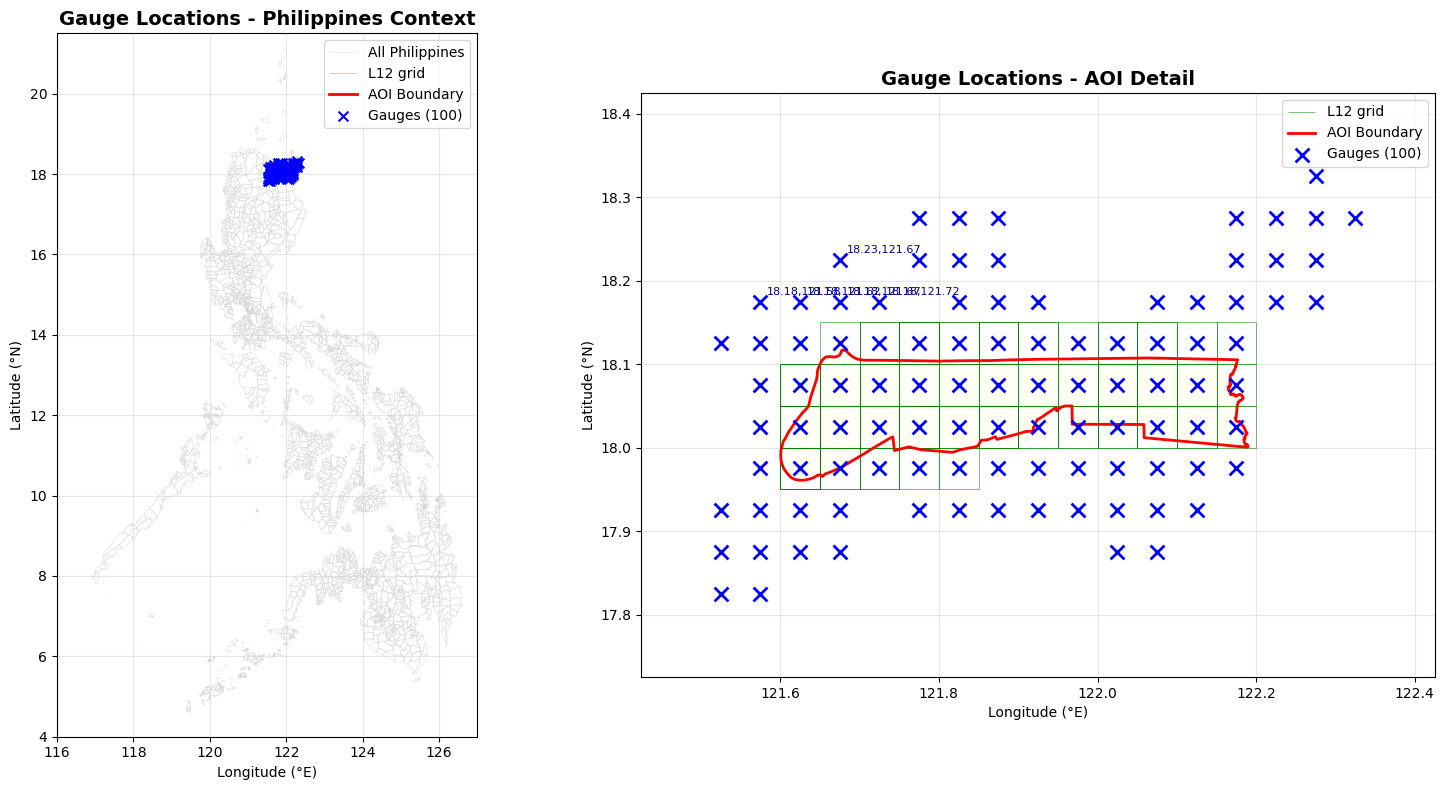


✅ Map visualization generated successfully
   Left: Philippines context showing all gauges relative to country
   Right: Zoomed to AOI showing gauge distribution detail

📊 COORDINATE VALIDATION SUMMARY
   Coordinate parsing................................ ✅ PASS
   Geographic bounds................................. ✅ PASS
   CRS verification.................................. ✅ PASS
   AOI filtering..................................... ❌ FAIL
   Coordinate format................................. ✅ PASS (Decimal degrees)

✅ COORDINATE VALIDATION COMPLETE
   Total gauges validated: 100
   Geographic range: 17.8250° to 18.3250°N, 121.5250° to 122.3250°E
   CRS: EPSG:4326


In [42]:
# COORDINATE VALIDATION CELL
import matplotlib.pyplot as plt
import warnings

print("="*80)
print("🗺️ COORDINATE VALIDATION: Geographic Accuracy Check")
print("="*80)

# ============================================================================
# 1. COORDINATE PARSING VALIDATION
# ============================================================================
print("\n📍 1) COORDINATE PARSING ACCURACY")
print("-" * 80)

# Test the parsing function with sample gauges
test_samples = evt_params.head(3)
print("Testing coordinate parsing on sample gauges:")
for idx, row in test_samples.iterrows():
    gid = row["virtual_gauge_id"]
    lat_parsed = row["lat"]
    lon_parsed = row["lon"]
    
    # Re-parse to verify consistency
    lat_check, lon_check = parse_lat_lon_from_gauge_id(gid)
    
    match = (lat_parsed == lat_check) and (lon_parsed == lon_check)
    status = "✅" if match else "❌"
    
    print(f"\n{status} Gauge: {gid}")
    print(f"   Parsed:    lat={lat_parsed:.4f}, lon={lon_parsed:.4f}")
    print(f"   Re-check:  lat={lat_check:.4f}, lon={lon_check:.4f}")
    print(f"   Match: {match}")

# Check for any parsing failures
try:
    all_parsed = evt_params.apply(
        lambda r: parse_lat_lon_from_gauge_id(r["virtual_gauge_id"]),
        axis=1
    )
    print(f"\n✅ All {len(evt_params)} gauge IDs parsed successfully")
except Exception as e:
    print(f"\n❌ ERROR: Parsing failed - {e}")

# ============================================================================
# 2. GEOGRAPHIC BOUNDS VALIDATION (Philippines Region)
# ============================================================================
print("\n" + "="*80)
print("🌏 2) GEOGRAPHIC BOUNDS CHECK (Philippines Region)")
print("-" * 80)

# Philippines approximate bounds: 4°N to 21°N, 116°E to 127°E
PHL_LAT_MIN, PHL_LAT_MAX = 4.0, 21.5
PHL_LON_MIN, PHL_LON_MAX = 116.0, 127.0

lat_min, lat_max = evt_params["lat"].min(), evt_params["lat"].max()
lon_min, lon_max = evt_params["lon"].min(), evt_params["lon"].max()

print(f"\nGauge coordinate ranges:")
print(f"   Latitude:  {lat_min:.4f}° to {lat_max:.4f}°")
print(f"   Longitude: {lon_min:.4f}° to {lon_max:.4f}°")
print(f"\nPhilippines expected ranges:")
print(f"   Latitude:  {PHL_LAT_MIN}° to {PHL_LAT_MAX}°")
print(f"   Longitude: {PHL_LON_MIN}° to {PHL_LON_MAX}°")

# Check if coordinates fall within Philippines
lat_in_bounds = (lat_min >= PHL_LAT_MIN) and (lat_max <= PHL_LAT_MAX)
lon_in_bounds = (lon_min >= PHL_LON_MIN) and (lon_max <= PHL_LON_MAX)

if lat_in_bounds and lon_in_bounds:
    print(f"\n✅ All coordinates fall within Philippines bounds")
else:
    if not lat_in_bounds:
        print(f"\n⚠️ WARNING: Latitude range extends outside Philippines")
        if lat_min < PHL_LAT_MIN:
            print(f"   {(lat_min - PHL_LAT_MIN):.2f}° south of expected minimum")
        if lat_max > PHL_LAT_MAX:
            print(f"   {(lat_max - PHL_LAT_MAX):.2f}° north of expected maximum")
    
    if not lon_in_bounds:
        print(f"\n⚠️ WARNING: Longitude range extends outside Philippines")
        if lon_min < PHL_LON_MIN:
            print(f"   {(PHL_LON_MIN - lon_min):.2f}° west of expected minimum")
        if lon_max > PHL_LON_MAX:
            print(f"   {(lon_max - PHL_LON_MAX):.2f}° east of expected maximum")

# Identify any out-of-bounds gauges
out_of_bounds = evt_params[
    (evt_params["lat"] < PHL_LAT_MIN) | (evt_params["lat"] > PHL_LAT_MAX) |
    (evt_params["lon"] < PHL_LON_MIN) | (evt_params["lon"] > PHL_LON_MAX)
]
if len(out_of_bounds) > 0:
    print(f"\n⚠️ {len(out_of_bounds)} gauge(s) outside Philippines bounds:")
    for _, row in out_of_bounds.head(5).iterrows():
        print(f"   {row['virtual_gauge_id']} → lat={row['lat']:.4f}, lon={row['lon']:.4f}")
else:
    print(f"\n✅ All {len(evt_params)} gauges within Philippines geographic bounds")

# ============================================================================
# 3. CRS CONSISTENCY CHECK
# ============================================================================
print("\n" + "="*80)
print("🌐 3) CRS (Coordinate Reference System) VERIFICATION")
print("-" * 80)

print(f"\nExpected CRS: EPSG:4326 (WGS84 - World Geodetic System 1984)")
print(f"   - Units: Decimal degrees")
print(f"   - Used by: GPS, GloFAS, most global datasets")

print(f"\nevt_points GeoDataFrame CRS: {evt_points.crs}")
print(f"AOI_BOUNDARY type: {type(AOI_BOUNDARY).__name__}")

if evt_points.crs and evt_points.crs.to_string() == "EPSG:4326":
    print(f"✅ evt_points CRS is correctly set to EPSG:4326")
else:
    print(f"⚠️ WARNING: evt_points CRS mismatch!")

# Check if coordinates are in decimal degrees (typical range for lat/lon)
if (-90 <= lat_min <= 90) and (-180 <= lon_min <= 180):
    print(f"✅ Coordinate values are consistent with decimal degrees")
else:
    print(f"❌ ERROR: Coordinate values don't look like decimal degrees!")

# ============================================================================
# 4. SPATIAL FILTERING ACCURACY (AOI Intersection)
# ============================================================================
print("\n" + "="*80)
print("🎯 4) SPATIAL FILTERING ACCURACY (AOI Intersection)")
print("-" * 80)

# Verify the spatial filtering worked correctly
print(f"\nBefore AOI filtering: {len(evt_params) + len(in_params_not_in_ts) if 'in_params_not_in_ts' in globals() else 'N/A'} gauges (from full calibration)")
print(f"After AOI filtering:  {len(evt_params)} gauges")

# Check if any gauges are exactly ON the AOI boundary (edge case)
on_boundary = evt_points[evt_points.geometry.touches(AOI_BOUNDARY)]
if len(on_boundary) > 0:
    print(f"\n📍 {len(on_boundary)} gauge(s) are exactly on the AOI boundary")
    
# Verify all gauges are truly inside or intersecting AOI
inside_count = evt_points.geometry.within(AOI_BOUNDARY).sum()
intersect_count = evt_points.geometry.intersects(AOI_BOUNDARY).sum()

print(f"\nSpatial relationship to AOI:")
print(f"   Inside (within): {inside_count} gauges")
print(f"   Intersecting:    {intersect_count} gauges")
print(f"   Total selected:  {len(evt_points)} gauges")

if intersect_count == len(evt_points):
    print(f"\n✅ All selected gauges correctly intersect the AOI")
else:
    print(f"\n❌ ERROR: {len(evt_points) - intersect_count} gauges don't intersect AOI!")

# ============================================================================
# 5. COORDINATE-FILENAME MATCHING
# ============================================================================
print("\n" + "="*80)
print("📁 5) COORDINATE-FILENAME CONSISTENCY CHECK")
print("-" * 80)

# Check if timeseries filenames match the coordinates
if TIMESERIES_DIR.exists():
    sample_gauge = evt_params.iloc[0]
    gid = sample_gauge["virtual_gauge_id"]
    expected_file = TIMESERIES_DIR / f"{gid}.parquet"
    
    print(f"\nSample check:")
    print(f"   Gauge ID: {gid}")
    print(f"   Extracted lat: {sample_gauge['lat']:.4f}")
    print(f"   Extracted lon: {sample_gauge['lon']:.4f}")
    print(f"   Expected filename: {expected_file.name}")
    print(f"   File exists: {expected_file.exists()}")
    
    if expected_file.exists():
        print(f"\n✅ Filename matches coordinate convention")
    else:
        print(f"\n⚠️ WARNING: Expected file not found (may be filtered out)")

# ============================================================================
# 6. VISUAL MAP VERIFICATION
# ============================================================================
print("\n" + "="*80)
print("🗺️ 6) VISUAL MAP VERIFICATION")
print("-" * 80)

try:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
    
    # Left plot: Full Philippines context
    ax1.set_title("Gauge Locations - Philippines Context", fontsize=14, fontweight='bold')
    
    # Plot Philippines boundary (ADM3)
    adm3_gdf.boundary.plot(ax=ax1, linewidth=0.5, color='lightgray', alpha=0.5, label='All Philippines')
    
    # L12 grid cells (from mapping)
    l12_plot = None
    if "l12_cells_sel_gdf" in globals() and l12_cells_sel_gdf is not None and len(l12_cells_sel_gdf) > 0:
        l12_plot = l12_cells_sel_gdf
    elif "l12_cells_gdf" in globals() and l12_cells_gdf is not None:
        l12_plot = l12_cells_gdf[l12_cells_gdf.intersects(AOI_BOUNDARY)].copy()
    if l12_plot is not None and not l12_plot.empty:
        l12_plot.boundary.plot(ax=ax1, linewidth=0.4, color='green', alpha=0.5, label='L12 grid')
    
    # Plot AOI boundary
    if hasattr(AOI_BOUNDARY, 'exterior'):
        # Single polygon
        xs, ys = AOI_BOUNDARY.exterior.xy
        ax1.plot(xs, ys, color='red', linewidth=2, label='AOI Boundary')
    elif hasattr(AOI_BOUNDARY, 'geoms'):
        # MultiPolygon
        for geom in AOI_BOUNDARY.geoms:
            xs, ys = geom.exterior.xy
            ax1.plot(xs, ys, color='red', linewidth=2)
        ax1.plot([], [], color='red', linewidth=2, label='AOI Boundary')
    
    # Plot virtual gauges
    evt_points.plot(ax=ax1, markersize=50, marker='x', color='blue', label=f'Gauges ({len(evt_points)})', zorder=5)
    
    # Set Philippines bounds
    ax1.set_xlim(PHL_LON_MIN, PHL_LON_MAX)
    ax1.set_ylim(PHL_LAT_MIN, PHL_LAT_MAX)
    ax1.set_xlabel('Longitude (°E)', fontsize=10)
    ax1.set_ylabel('Latitude (°N)', fontsize=10)
    ax1.legend(loc='best', fontsize=10)
    ax1.grid(True, alpha=0.3)
    
    # Right plot: Zoomed to AOI
    ax2.set_title("Gauge Locations - AOI Detail", fontsize=14, fontweight='bold')
    
    # L12 grid cells (from mapping)
    if l12_plot is not None and not l12_plot.empty:
        l12_plot.boundary.plot(ax=ax2, linewidth=0.6, color='green', alpha=0.6, label='L12 grid')
    
    # Plot AOI boundary
    if hasattr(AOI_BOUNDARY, 'exterior'):
        xs, ys = AOI_BOUNDARY.exterior.xy
        ax2.fill(xs, ys, color='lightyellow', alpha=0.3, label='AOI')
        ax2.plot(xs, ys, color='red', linewidth=2, label='AOI Boundary')
    elif hasattr(AOI_BOUNDARY, 'geoms'):
        for geom in AOI_BOUNDARY.geoms:
            xs, ys = geom.exterior.xy
            ax2.fill(xs, ys, color='lightyellow', alpha=0.3)
            ax2.plot(xs, ys, color='red', linewidth=2)
        ax2.plot([], [], color='red', linewidth=2, label='AOI Boundary')
    
    # Plot gauges
    evt_points.plot(ax=ax2, markersize=100, marker='x', color='blue', linewidth=2, label=f'Gauges ({len(evt_points)})', zorder=5)
    
    # Add gauge labels for first 5 gauges (to avoid clutter)
    for idx, row in evt_points.head(5).iterrows():
        ax2.annotate(
            f"{row['lat']:.2f},{row['lon']:.2f}",
            xy=(row.geometry.x, row.geometry.y),
            xytext=(5, 5), textcoords='offset points',
            fontsize=8, color='darkblue'
        )
    
    # Zoom to AOI with padding
    bounds = evt_points.total_bounds  # minx, miny, maxx, maxy
    padding = 0.1  # degrees
    ax2.set_xlim(bounds[0] - padding, bounds[2] + padding)
    ax2.set_ylim(bounds[1] - padding, bounds[3] + padding)
    ax2.set_xlabel('Longitude (°E)', fontsize=10)
    ax2.set_ylabel('Latitude (°N)', fontsize=10)
    ax2.legend(loc='best', fontsize=10)
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n✅ Map visualization generated successfully")
    print(f"   Left: Philippines context showing all gauges relative to country")
    print(f"   Right: Zoomed to AOI showing gauge distribution detail")

except Exception as e:
    print(f"\n⚠️ Could not generate map visualization: {e}")

# ============================================================================
# SUMMARY
# ============================================================================
print("\n" + "="*80)
print("📊 COORDINATE VALIDATION SUMMARY")
print("="*80)

validation_results = {
    "Coordinate parsing": "✅ PASS" if len(evt_params) > 0 else "❌ FAIL",
    "Geographic bounds": "✅ PASS" if (lat_in_bounds and lon_in_bounds) else "⚠️ WARNING",
    "CRS verification": "✅ PASS" if evt_points.crs.to_string() == "EPSG:4326" else "⚠️ WARNING",
    "AOI filtering": "✅ PASS" if intersect_count == len(evt_points) else "❌ FAIL",
    "Coordinate format": "✅ PASS (Decimal degrees)" if (-90 <= lat_min <= 90) else "❌ FAIL",
}

for check, status in validation_results.items():
    print(f"   {check:.<50} {status}")

print(f"\n" + "="*80)
print(f"✅ COORDINATE VALIDATION COMPLETE")
print(f"   Total gauges validated: {len(evt_params)}")
print(f"   Geographic range: {lat_min:.4f}° to {lat_max:.4f}°N, {lon_min:.4f}° to {lon_max:.4f}°E")
print(f"   CRS: {evt_points.crs}")
print(f"=" * 80)

## 7) JRC flood maps (download if needed) + Depth interpolation (Notebook 02 logic)

Downloads and processes JRC global flood depth maps, then interpolates to return period grid.

**Steps**:
1. **Tile selection**: Downloads JRC tile index, selects tiles covering AOI
2. **Tile download**: Downloads flood depth maps for all 8 return periods (10-500 years)
3. **Mosaicking**: Merges tiles into single grid per RP
4. **Regridding**: Interpolates to match RP grid (bilinear method)
5. **Depth computation**: Uses CLIMADA-Petals `petals_flood_depth()` to interpolate depths

**Output**: `depth_model__validation__*.tif` files (one per episode × RP label × scenario)

**Duration**: 30-60+ minutes first time (downloading); subsequent runs use cached tiles.

**Optional**: FLOPROS flood protection scenarios (toggle `ENABLE_FLOPROS_SCENARIOS`)

In [43]:
import requests

JRC_BASE_URL = "https://jeodpp.jrc.ec.europa.eu/ftp/jrc-opendata/CEMS-GLOFAS/flood_hazard/"
JRC_RETURN_PERIODS = [10, 20, 50, 75, 100, 200, 500]
USE_RECLASSIFIED = False

JRC_CACHE = JRC_RAW_ROOT
JRC_CACHE.mkdir(parents=True, exist_ok=True)

tile_index_path = JRC_CACHE / "tile_extents.geojson"
if not tile_index_path.exists():
    print("Downloading tile_extents.geojson ...")
    resp = requests.get(JRC_BASE_URL + "tile_extents.geojson", timeout=120)
    resp.raise_for_status()
    tile_index_path.write_bytes(resp.content)

tiles_gdf = gpd.read_file(tile_index_path).to_crs("EPSG:4326")
tiles_sel = tiles_gdf[tiles_gdf.intersects(AOI_BOUNDARY)].copy()
tiles_sel["tile_code"] = "ID" + tiles_sel["id"].astype(str) + "_" + tiles_sel["name"].astype(str)
tile_codes = sorted(tiles_sel["tile_code"].unique().tolist())
print("Selected JRC tiles:", len(tile_codes), "example:", tile_codes[:3])

def download_jrc_tile(rp: int, tile_code: str, output_dir: Path) -> Optional[Path]:
    suffix = "_depth_reclass.tif" if USE_RECLASSIFIED else "_depth.tif"
    fname = f"{tile_code}_RP{rp}{suffix}"
    out_path = output_dir / fname

    if out_path.exists() and out_path.stat().st_size > 0:
        return out_path

    url = f"{JRC_BASE_URL}RP{rp}/{fname}"
    try:
        r = requests.get(url, stream=True, timeout=300)
        r.raise_for_status()
        with open(out_path, "wb") as f:
            for chunk in r.iter_content(chunk_size=1024*1024):
                if chunk:
                    f.write(chunk)
        return out_path
    except Exception as e:
        print("⚠️ Download failed:", url, "->", e)
        return None

manifest = []
for rp in JRC_RETURN_PERIODS:
    rp_dir = JRC_CACHE / f"RP{rp}"
    rp_dir.mkdir(exist_ok=True)
    ok = 0
    for tc in tile_codes:
        p = download_jrc_tile(rp, tc, rp_dir)
        if p:
            ok += 1
            manifest.append({"rp": rp, "tile_code": tc, "path": str(p)})
    print(f"RP{rp}: {ok}/{len(tile_codes)} tiles available")

if len(manifest) == 0:
    raise RuntimeError("No JRC tiles available (download failed or cache empty).")

from rasterio.merge import merge as rio_merge

flood_maps_path = OUT_DIR / "jrc" / "flood-maps_intermediate.nc"
flood_maps_path.parent.mkdir(parents=True, exist_ok=True)

if flood_maps_path.exists():
    flood_maps = xr.open_dataarray(flood_maps_path)
    print("Using cached flood_maps:", flood_maps.shape)
else:
    suffix = "_depth_reclass.tif" if USE_RECLASSIFIED else "_depth.tif"
    flood_maps_list = []
    for rp in JRC_RETURN_PERIODS:
        rp_dir = JRC_CACHE / f"RP{rp}"
        tile_paths = [rp_dir / f"{tc}_RP{rp}{suffix}" for tc in tile_codes]
        tile_paths = [p for p in tile_paths if p.exists()]
        if not tile_paths:
            continue

        srcs = [rasterio.open(str(p)) for p in tile_paths]
        mosaic, out_trans = rio_merge(srcs)
        for s in srcs:
            s.close()

        arr = mosaic[0].astype("float32")
        h,w = arr.shape

        lons = out_trans.c + out_trans.a * (np.arange(w) + 0.5)
        lats = out_trans.f + out_trans.e * (np.arange(h) + 0.5)
        
        # ✓ FIX: Don't flip lats/array - rasterio expects descending lats (north→south)
        # This ensures lats.max() truly represents the northern edge for transform creation
        # (Previous flip caused vertical inversion in GeoTIFF output)
        
        da = xr.DataArray(
            arr,
            coords={"latitude": lats, "longitude": lons},
            dims=("latitude","longitude"),
            name="depth"
        ).expand_dims({"return_period":[rp]})

        flood_maps_list.append(da)

    flood_maps = xr.concat(flood_maps_list, dim="return_period")
    flood_maps.to_netcdf(flood_maps_path)
    print("Saved flood_maps:", flood_maps_path)

print("JRC flood_maps return periods:", list(flood_maps.return_period.values))

DEPTH_OUT_DIR = OUT_DIR / "model" / "depth"
DEPTH_OUT_DIR.mkdir(parents=True, exist_ok=True)

REGRID_METHOD = "bilinear"

def _coord_bounds(source: xr.DataArray, coord: str) -> Tuple[float, float]:
    vals = source[coord].values
    return float(np.nanmin(vals)), float(np.nanmax(vals))

def sel_lon_lat_slice(target: xr.DataArray, source: xr.DataArray) -> xr.DataArray:
    """Select a lon/lat slice from 'target' using coordinate bounds of 'source'."""
    bounds = {}
    for coord in ["longitude", "latitude"]:
        lo, hi = _coord_bounds(source, coord)
        tgt_vals = target[coord].values
        descending = tgt_vals[0] > tgt_vals[-1]
        bounds[coord] = slice(hi, lo) if descending else slice(lo, hi)
    return target.sel(bounds)

def load_rp_da(path_nc: Path) -> xr.DataArray:
    """Load return period grid with proper spatial coordinates from NetCDF."""
    ds = xr.open_dataset(path_nc)
    da = ds["return_period"]
    # Ensure latitude and longitude coordinates are properly attached
    if "latitude" not in da.coords:
        da = da.assign_coords({"latitude": ds["latitude"]})
    if "longitude" not in da.coords:
        da = da.assign_coords({"longitude": ds["longitude"]})
    return da

def _fmt_bounds(da: xr.DataArray) -> str:
    lat_min, lat_max = _coord_bounds(da, "latitude")
    lon_min, lon_max = _coord_bounds(da, "longitude")
    return f"lat[{lat_min:.4f},{lat_max:.4f}] lon[{lon_min:.4f},{lon_max:.4f}]"

def _ensure_lon_lat_coords(da: xr.DataArray) -> xr.DataArray:
    if "lon" not in da.coords and "longitude" in da.coords:
        da = da.assign_coords(lon=da["longitude"])
    if "lat" not in da.coords and "latitude" in da.coords:
        da = da.assign_coords(lat=da["latitude"])
    return da

def _match_coord_order(source: xr.DataArray, target: xr.DataArray) -> xr.DataArray:
    source_lat_desc = source["latitude"].values[0] > source["latitude"].values[-1]
    target_lat_desc = target["latitude"].values[0] > target["latitude"].values[-1]
    if source_lat_desc != target_lat_desc:
        source = source.sortby("latitude", ascending=not target_lat_desc)
    source_lon_desc = source["longitude"].values[0] > source["longitude"].values[-1]
    target_lon_desc = target["longitude"].values[0] > target["longitude"].values[-1]
    if source_lon_desc != target_lon_desc:
        source = source.sortby("longitude", ascending=not target_lon_desc)
    return source

def _da_stats(da: xr.DataArray, label: str) -> None:
    arr = da.values
    finite = np.isfinite(arr)
    n = int(finite.sum())
    total = int(arr.size)
    if n > 0:
        mn = float(np.nanmin(arr))
        mx = float(np.nanmax(arr))
        print(f"{label}: finite={n}/{total} min={mn:.3f} max={mx:.3f}")
    else:
        print(f"{label}: finite=0/{total}")

def _sanitize_rp(da: xr.DataArray) -> xr.DataArray:
    # RP values below 1 are invalid for flood depth logic; treat as missing
    return da.where(da >= 1.0)

def apply_flopros_if_needed(rp_regrid: xr.DataArray, apply: bool, flopros_root: Path) -> xr.DataArray:
    if not apply:
        return rp_regrid
    try:
        flopros_shp = flopros_root / "FLOPROS_shp_V1" / "FLOPROS_shp_V1.shp"
        if not flopros_shp.exists():
            print("Downloading FLOPROS database ...")
            download_flopros_database(str(flopros_root))
        flopros_gdf = gpd.read_file(flopros_shp).to_crs("EPSG:4326")
        overlap = int(flopros_gdf.intersects(AOI_BOUNDARY).sum())
        print(f"FLOPROS AOI overlap polygons: {overlap}")

        protected_list = []
        for i, ep in enumerate(rp_regrid.event.values):
            rp_event = _sanitize_rp(rp_regrid.isel(event=i).copy(deep=True))
            _da_stats(rp_event, f"FLOPROS pre-mask {ep}")
            if overlap == 0:
                print("FLOPROS: no AOI overlap; skipping protection mask")
                rp_prot = rp_event
            else:
                rp_prot = petals_apply_flopros(flopros_gdf, rp_event, layer="MerL_Riv")
            _da_stats(rp_prot, f"FLOPROS post-mask {ep}")
            protected_list.append(rp_prot.expand_dims({"event":[ep]}))
        return xr.concat(protected_list, dim="event")
    except Exception as e:
        print("⚠️ FLOPROS failed; continuing without protection:", e)
        return rp_regrid

def compute_depth_from_rp(rp_da: xr.DataArray, ep_id: str, rp_label: str, apply_flopros: bool) -> Path:
    # Create properly-structured 3D array with event dimension
    # Ensure dimensions are named: (event, latitude, longitude)
    rp_da_3d = rp_da.expand_dims({"event": [ep_id]})
    rp_da_3d = _ensure_lon_lat_coords(rp_da_3d)
    rp_da_3d = _sanitize_rp(rp_da_3d)
    
    # Verify coordinates before regridding
    assert "latitude" in rp_da_3d.coords or "latitude" in rp_da_3d.dims, f"Missing latitude coordinate/dimension"
    assert "longitude" in rp_da_3d.coords or "longitude" in rp_da_3d.dims, f"Missing longitude coordinate/dimension"
    
    # Crop flood_maps to AOI extent using return period bounds (matches notebook 2 approach)
    flood_maps_sel = sel_lon_lat_slice(flood_maps, rp_da_3d)
    flood_maps_sel = _ensure_lon_lat_coords(flood_maps_sel)
    if "latitude" not in flood_maps_sel.dims or "longitude" not in flood_maps_sel.dims:
        raise ValueError(f"flood_maps_sel missing lat/lon dims: {flood_maps_sel.dims}")
    if flood_maps_sel.sizes.get("latitude", 0) == 0 or flood_maps_sel.sizes.get("longitude", 0) == 0:
        print("⚠️ Empty flood_maps selection for regrid")
        print("   rp_da_3d:", _fmt_bounds(rp_da_3d))
        print("   flood_maps:", _fmt_bounds(flood_maps))
        raise ValueError("No overlap between return-period grid and JRC flood maps. Check AOI and data bounds.")
    
    rp_da_3d = _match_coord_order(rp_da_3d, flood_maps_sel)
    
    # Regrid to match flood_maps grid
    rp_regrid = petals_regrid(rp_da_3d, flood_maps_sel, method=REGRID_METHOD)
    rp_regrid = _sanitize_rp(rp_regrid)
    rp_regrid = apply_flopros_if_needed(rp_regrid, apply_flopros, flopros_root=OUT_DIR / "jrc")
    depth = petals_flood_depth(rp_regrid, flood_maps_sel).isel(event=0)

    scenario = "FLOPROS" if apply_flopros else "NoProt"
    out_tif = DEPTH_OUT_DIR / f"depth_model__validation__{ep_id}__{rp_label}__{scenario}.tif"

    lats = depth.latitude.values
    lons = depth.longitude.values
    res_lon = float(np.mean(np.diff(lons)))
    res_lat = float(np.mean(np.diff(lats)))
    west = float(lons.min() - res_lon/2)
    north = float(lats.max() + abs(res_lat)/2)
    
    # ✓ Transform: lats should be descending (north→south) so lats.max() is truly north
    # from_origin expects (west, north) corner with positive pixel sizes
    transform = rasterio.transform.from_origin(west, north, res_lon, abs(res_lat))

    meta = {
        "driver":"GTiff",
        "height": depth.shape[0],
        "width": depth.shape[1],
        "count":1,
        "dtype":"float32",
        "crs":"EPSG:4326",
        "transform": transform,
        "nodata": np.nan
    }
    with rasterio.open(out_tif, "w", **meta) as dst:
        dst.write(depth.values.astype("float32"), 1)
    return out_tif

depth_products = []
for _, row in rp_df.iterrows():
    ep_id = row["episode_id"]
    for rp_label, path_nc in [("envelope", Path(row["envelope"])), ("peakday", Path(row["peakday"]))]:
        rp_da = load_rp_da(path_nc)
        scenarios = [False] + ([True] if ENABLE_FLOPROS_SCENARIOS else [])
        for do_flopros in scenarios:
            out_tif = compute_depth_from_rp(rp_da, ep_id, rp_label, apply_flopros=do_flopros)
            depth_products.append({
                "episode_id": ep_id,
                "rp_label": rp_label,
                "scenario": "FLOPROS" if do_flopros else "NoProt",
                "depth_tif": str(out_tif)
            })

depth_df = pd.DataFrame(depth_products)
display(depth_df)

Selected JRC tiles: 1 example: ['ID231_N20_E120']
RP10: 1/1 tiles available
RP20: 1/1 tiles available
RP50: 1/1 tiles available
RP75: 1/1 tiles available
RP100: 1/1 tiles available
RP200: 1/1 tiles available
RP500: 1/1 tiles available
Using cached flood_maps: (7, 11999, 11999)
JRC flood_maps return periods: [10, 20, 50, 75, 100, 200, 500]
FLOPROS AOI overlap polygons: 1
FLOPROS pre-mask EP01_20201113_20201116: finite=576000/576000 min=1.026 max=17.561
FLOPROS post-mask EP01_20201113_20201116: finite=244081/576000 min=12.315 max=17.561
FLOPROS AOI overlap polygons: 1
FLOPROS pre-mask EP01_20201113_20201116: finite=576000/576000 min=1.126 max=4.417
FLOPROS post-mask EP01_20201113_20201116: finite=0/576000
FLOPROS AOI overlap polygons: 1
FLOPROS pre-mask EP02_20221025_20221025: finite=576000/576000 min=1.235 max=3.829
FLOPROS post-mask EP02_20221025_20221025: finite=0/576000
FLOPROS AOI overlap polygons: 1
FLOPROS pre-mask EP02_20221025_20221025: finite=576000/576000 min=1.235 max=3.829
F

,episode_id,rp_label,scenario,depth_tif
0,EP01_20201113_20201116,envelope,NoProt,C:\pipelines\GLOFAS_ImpactFloodForecasting_PHL...
1,EP01_20201113_20201116,envelope,FLOPROS,C:\pipelines\GLOFAS_ImpactFloodForecasting_PHL...
2,EP01_20201113_20201116,peakday,NoProt,C:\pipelines\GLOFAS_ImpactFloodForecasting_PHL...
3,EP01_20201113_20201116,peakday,FLOPROS,C:\pipelines\GLOFAS_ImpactFloodForecasting_PHL...
4,EP02_20221025_20221025,envelope,NoProt,C:\pipelines\GLOFAS_ImpactFloodForecasting_PHL...
5,EP02_20221025_20221025,envelope,FLOPROS,C:\pipelines\GLOFAS_ImpactFloodForecasting_PHL...
6,EP02_20221025_20221025,peakday,NoProt,C:\pipelines\GLOFAS_ImpactFloodForecasting_PHL...
7,EP02_20221025_20221025,peakday,FLOPROS,C:\pipelines\GLOFAS_ImpactFloodForecasting_PHL...
8,EP03_20241026_20241029,envelope,NoProt,C:\pipelines\GLOFAS_ImpactFloodForecasting_PHL...
9,EP03_20241026_20241029,envelope,FLOPROS,C:\pipelines\GLOFAS_ImpactFloodForecasting_PHL...


## 8) Hazard extent validation (observed vs modelled)

**Core validation step**: Compares modeled vs. observed flood extent quantitatively.

**Steps**:
1. **Reprojection**: Transforms observed GFM extent to model grid (nearest neighbor)
2. **Confusion matrix** at multiple depth thresholds (0.05-1.0 m):
   - **TP** (True Positive): Correctly predicted flood
   - **FP** (False Positive): Over-predicted (false alarm)
   - **FN** (False Negative): Under-predicted (missed)
   - **TN** (True Negative): Correctly predicted non-flood
3. **Derived metrics**: Precision, Recall, F1, IoU, Bias
4. **Difference maps**: 4-class maps (TP=1, FP=2, FN=3, TN=0)

**Output**: `hazard_extent_metrics.csv` + diff maps in `maps_for_dashboard/`

**Metrics guide**: See [GLOSSARY - Validation Metrics](../../docs/technical/GLOSSARY.md#validation--metrics-notebook-03)

In [44]:

METRICS_OUT_DIR = OUT_DIR / "metrics"
MAPS_OUT_DIR = OUT_DIR / "maps_for_dashboard"
METRICS_OUT_DIR.mkdir(parents=True, exist_ok=True)
MAPS_OUT_DIR.mkdir(parents=True, exist_ok=True)

def read_raster(path: Path) -> Tuple[np.ndarray, dict]:
    with rasterio.open(path) as src:
        arr = src.read(1)
        meta = src.meta.copy()
    return arr, meta

def reproject_to_match(src_arr, src_meta, dst_meta, dst_shape) -> np.ndarray:
    dst = np.full(dst_shape, np.nan, dtype="float32")
    reproject(
        source=src_arr.astype("float32"),
        destination=dst,
        src_transform=src_meta["transform"],
        src_crs=src_meta.get("crs", "EPSG:4326"),
        dst_transform=dst_meta["transform"],
        dst_crs=dst_meta.get("crs", "EPSG:4326"),
        resampling=Resampling.nearest,
        src_nodata=src_meta.get("nodata", 255),
        dst_nodata=np.nan
    )
    return dst

def confusion_metrics(obs: np.ndarray, mod: np.ndarray, valid_mask: np.ndarray) -> Dict[str,float]:
    o = obs[valid_mask].astype(int)
    m = mod[valid_mask].astype(int)
    tp = int(((o==1) & (m==1)).sum())
    fp = int(((o==0) & (m==1)).sum())
    fn = int(((o==1) & (m==0)).sum())
    tn = int(((o==0) & (m==0)).sum())
    precision = tp / (tp+fp) if (tp+fp)>0 else np.nan
    recall = tp / (tp+fn) if (tp+fn)>0 else np.nan
    f1 = 2*precision*recall/(precision+recall) if np.isfinite(precision) and np.isfinite(recall) and (precision+recall)>0 else np.nan
    iou = tp / (tp+fp+fn) if (tp+fp+fn)>0 else np.nan
    bias = (tp+fp) / (tp+fn) if (tp+fn)>0 else np.nan
    return {"tp":tp,"fp":fp,"fn":fn,"tn":tn,"precision":precision,"recall":recall,"f1":f1,"iou":iou,"bias":bias}

def make_diff_map(obs_bin, mod_bin, valid_mask) -> np.ndarray:
    out = np.full(obs_bin.shape, 255, dtype=np.uint8)
    out[valid_mask] = 0
    out[(valid_mask) & (obs_bin==1) & (mod_bin==1)] = 1  # TP
    out[(valid_mask) & (obs_bin==0) & (mod_bin==1)] = 2  # FP
    out[(valid_mask) & (obs_bin==1) & (mod_bin==0)] = 3  # FN
    return out

# Template grid from first depth raster
depth0_path = Path(depth_df["depth_tif"].iloc[0])
depth0_arr, depth0_meta = read_raster(depth0_path)
dst_shape = depth0_arr.shape

# Validate projection metadata
print("\n🔍 **CRS Validation & Projection Metadata**")
depth0_crs = depth0_meta.get("crs", "EPSG:4326")
print(f"Depth map CRS: {depth0_crs}")
print(f"Depth map shape: {dst_shape}")
print(f"Depth map transform (affine): {depth0_meta['transform']}")

# Verify depth map bounds (sanity check)
trans = depth0_meta['transform']
west = trans.c
north = trans.f
east = west + trans.a * depth0_meta['width']
south = north + trans.e * depth0_meta['height']
print(f"Depth map bounds (west, south, east, north): ({west:.4f}, {south:.4f}, {east:.4f}, {north:.4f})")

# Cache observed (episode max) reprojected to JRC grid
obs_reproj_cache = {}
print("\n🔍 **Observed Flood Map Reprojection**")
for _, ep in episode_df.iterrows():
    ep_id = ep["episode_id"]
    obs_path = Path(ep["path"])
    obs_arr, obs_meta = read_raster(obs_path)
    
    # Validate obs CRS
    obs_crs = obs_meta.get("crs", "EPSG:4326")
    if obs_crs != depth0_crs:
        print(f"⚠️ Episode {ep_id}: CRS mismatch - obs={obs_crs}, depth={depth0_crs}")
    
    obs_float = np.where(obs_arr == 255, np.nan, obs_arr.astype("float32"))
    obs_reproj = reproject_to_match(obs_float, obs_meta, depth0_meta, dst_shape)
    obs_bin = np.where(np.isfinite(obs_reproj) & (obs_reproj>=0.5), 1, 0).astype(np.uint8)
    valid_mask = np.isfinite(obs_reproj)
    obs_reproj_cache[ep_id] = (obs_bin, valid_mask)
    print(f"✓ {ep_id}: Reprojected to depth grid (shape={obs_reproj.shape}, valid pixels={valid_mask.sum():,})")

metrics_rows = []
for _, row in depth_df.iterrows():
    ep_id = row["episode_id"]
    rp_label = row["rp_label"]
    scenario = row["scenario"]

    depth_path = Path(row["depth_tif"])
    depth_arr, depth_meta = read_raster(depth_path)
    depth_arr = depth_arr.astype("float32")

    obs_bin, valid_mask = obs_reproj_cache[ep_id]

    for thr in DEPTH_THRESHOLDS_FOR_METRICS:
        mod_bin = np.where(np.isfinite(depth_arr) & (depth_arr >= thr), 1, 0).astype(np.uint8)
        met = confusion_metrics(obs_bin, mod_bin, valid_mask)
        metrics_rows.append({
            "episode_id": ep_id,
            "rp_label": rp_label,
            "scenario": scenario,
            "depth_threshold_m": thr,
            **met
        })

        diff = make_diff_map(obs_bin, mod_bin, valid_mask)
        diff_path = MAPS_OUT_DIR / f"diff__{ep_id}__{rp_label}__{scenario}__thr{thr:.2f}.tif"
        meta = depth_meta.copy()
        meta.update({"dtype": rasterio.uint8, "count":1, "nodata":255})
        with rasterio.open(diff_path, "w", **meta) as dst:
            dst.write(diff, 1)

metrics_df = pd.DataFrame(metrics_rows)
metrics_csv = METRICS_OUT_DIR / "hazard_extent_metrics.csv"
metrics_df.to_csv(metrics_csv, index=False)
print("Saved:", metrics_csv)
display(metrics_df.head(20))



🔍 **CRS Validation & Projection Metadata**
Depth map CRS: EPSG:4326
Depth map shape: (600, 960)
Depth map transform (affine): | 0.00, 0.00, 121.52|
| 0.00,-0.00, 18.33|
| 0.00, 0.00, 1.00|
Depth map bounds (west, south, east, north): (121.5246, 17.8254, 122.3246, 18.3254)

🔍 **Observed Flood Map Reprojection**
✓ EP01_20201113_20201116: Reprojected to depth grid (shape=(600, 960), valid pixels=78,522)
✓ EP02_20221025_20221025: Reprojected to depth grid (shape=(600, 960), valid pixels=75,997)
✓ EP03_20241026_20241029: Reprojected to depth grid (shape=(600, 960), valid pixels=78,408)
Saved: C:\pipelines\GLOFAS_ImpactFloodForecasting_PHL\data\processed\validation\MUNI_SELECTION\2026-01-19_calib-test\metrics\hazard_extent_metrics.csv


,episode_id,rp_label,scenario,depth_threshold_m,tp,fp,fn,tn,precision,recall,f1,iou,bias
0,EP01_20201113_20201116,envelope,NoProt,0.05,1889,3554,165,72914,0.347051,0.919669,0.503935,0.336840,2.649951
1,EP01_20201113_20201116,envelope,NoProt,0.10,1889,3554,165,72914,0.347051,0.919669,0.503935,0.336840,2.649951
2,EP01_20201113_20201116,envelope,NoProt,0.20,1889,3554,165,72914,0.347051,0.919669,0.503935,0.336840,2.649951
3,EP01_20201113_20201116,envelope,NoProt,0.50,1882,3531,172,72937,0.347682,0.916261,0.504085,0.336974,2.635346
4,EP01_20201113_20201116,envelope,NoProt,1.00,1817,3210,237,73258,0.361448,0.884615,0.513204,0.345175,2.447420
5,EP01_20201113_20201116,envelope,FLOPROS,0.05,1889,3517,165,72951,0.349427,0.919669,0.506434,0.339077,2.631938
6,EP01_20201113_20201116,envelope,FLOPROS,0.10,1889,3517,165,72951,0.349427,0.919669,0.506434,0.339077,2.631938
7,EP01_20201113_20201116,envelope,FLOPROS,0.20,1889,3517,165,72951,0.349427,0.919669,0.506434,0.339077,2.631938
8,EP01_20201113_20201116,envelope,FLOPROS,0.50,1882,3494,172,72974,0.350074,0.916261,0.506595,0.339221,2.617332
9,EP01_20201113_20201116,envelope,FLOPROS,1.00,1817,3173,237,73295,0.364128,0.884615,0.515900,0.347618,2.429406


## 9) Affected population proxy (WorldPop × depth ≥ threshold)

Estimates affected population as impact proxy (not true impact modeling).

**Steps**:
1. **Reprojection**: Regrid WorldPop to model grid (bilinear interpolation)
2. **Mass balance check**: Compare native vs. reprojected total population (warn if >10% change)
3. **Exposure calculation**: For each depth threshold:
   - Identify flooded areas (depth ≥ threshold)
   - Sum WorldPop within flood extent
   - Mask to ADM3 municipality boundaries
4. **GFM comparison**: Same calculation for observed extent (modeled vs. observed pop)

**Output**: `affected_population_by_adm3.csv`

**Columns**: episode_id, scenario, depth_threshold, adm3_name, affected_pop, observed_pop

**Note**: Population is a proxy only. Use to identify areas of concern, not absolute damage.

In [69]:

POP_OUT_DIR = OUT_DIR / "population"
POP_OUT_DIR.mkdir(parents=True, exist_ok=True)

if not WORLDPOP_RASTER.exists():
    raise FileNotFoundError(f"WorldPop raster not found: {WORLDPOP_RASTER}")

with rasterio.open(WORLDPOP_RASTER) as pop_src:
    pop_arr = pop_src.read(1).astype("float32")
    pop_meta = pop_src.meta.copy()
    pop_nodata = pop_src.nodata

# ---- Reproject WorldPop to JRC grid (NOTE: not perfectly mass-conserving in EPSG:4326) ----
# For stakeholder exploration, this is acceptable as a *proxy*, but we add a sanity check.
# Using bilinear for better visual quality in dashboard
POP_RESAMPLING = Resampling.bilinear

pop_reproj = np.full(dst_shape, np.nan, dtype="float32")
reproject(
    source=pop_arr,
    destination=pop_reproj,
    src_transform=pop_meta["transform"],
    src_crs=pop_meta.get("crs", "EPSG:4326"),
    dst_transform=depth0_meta["transform"],
    dst_crs=depth0_meta.get("crs", "EPSG:4326"),
    resampling=POP_RESAMPLING,
    src_nodata=pop_nodata,
    dst_nodata=np.nan
)

# ADM3 polygons intersecting AOI
adm3_aoi = adm3_gdf[adm3_gdf.intersects(AOI_BOUNDARY)].copy()
print("ADM3 intersecting AOI:", len(adm3_aoi))

from rasterio.features import geometry_mask

def polygon_mask(poly, meta) -> np.ndarray:
    """Boolean mask where True means *inside* the polygon."""
    return geometry_mask([poly], out_shape=(meta["height"], meta["width"]),
                         transform=meta["transform"], invert=True)

poly_masks = {str(row["adm3_id"]): polygon_mask(row.geometry, depth0_meta) for _, row in adm3_aoi.iterrows()}

# ---- Sanity check: compare total pop inside AOI before/after reprojection ----
def sum_worldpop_in_geom(pop_path: Path, geom) -> float:
    with rasterio.open(pop_path) as src:
        out_image, _ = rio_mask(src, [geom], crop=True, filled=False)
        a = out_image[0].astype("float32")
        nod = src.nodata
        if nod is not None:
            a = np.where(a == nod, np.nan, a)
        return float(np.nansum(a))

try:
    total_native = sum_worldpop_in_geom(WORLDPOP_RASTER, AOI_BOUNDARY)
    aoi_mask_jrc = polygon_mask(AOI_BOUNDARY, depth0_meta)
    total_reproj = float(np.nansum(np.where(aoi_mask_jrc, pop_reproj, np.nan)))
    if np.isfinite(total_native) and np.isfinite(total_reproj) and total_native > 0:
        ratio = total_reproj / total_native
        print(f"Population reprojection sanity: native={total_native:,.0f}  reprojected={total_reproj:,.0f}  ratio={ratio:.3f}")
        if abs(ratio - 1.0) > 0.10:
            print("⚠️  Warning: reprojection changes total population in AOI by >10%. Treat exposure numbers as approximate.")
except Exception as e:
    print("⚠️ Population sanity check skipped (masking failed):", e)

thr_grid = np.round(np.arange(DASHBOARD_THRESHOLD_MIN, DASHBOARD_THRESHOLD_MAX + 1e-9, DASHBOARD_THRESHOLD_STEP), 2).tolist()

affected_rows = []
for _, row in depth_df.iterrows():
    ep_id = row["episode_id"]
    rp_label = row["rp_label"]
    scenario = row["scenario"]

    depth_path = Path(row["depth_tif"])
    depth_arr, _ = read_raster(depth_path)
    depth_arr = depth_arr.astype("float32")

    for thr in thr_grid:
        flooded = np.isfinite(depth_arr) & (depth_arr >= thr)
        flooded_pop = np.where(flooded, pop_reproj, 0.0)

        for _, adm in adm3_aoi.iterrows():
            mid = str(adm["adm3_id"])
            mname = adm["adm3_name"]
            val = float(np.nansum(flooded_pop[poly_masks[mid]]))
            affected_rows.append({
                "episode_id": ep_id,
                "rp_label": rp_label,
                "scenario": scenario,
                "depth_threshold_m": float(thr),
                "adm3_id": mid,
                "adm3_name": mname,
                "affected_pop": val
            })

# ---- Compute GFM (observed) affected population for comparison ----
gfm_pop_rows = []
print("\n📊 Computing GFM-based affected population...")
for _, ep in episode_df.iterrows():
    ep_id = ep["episode_id"]
    obs_bin, valid_mask = obs_reproj_cache[ep_id]
    
    # GFM extent (binary: 0 or 1)
    flooded_gfm = (obs_bin == 1)
    flooded_gfm_pop = np.where(flooded_gfm, pop_reproj, 0.0)
    
    for _, adm in adm3_aoi.iterrows():
        mid = str(adm["adm3_id"])
        mname = adm["adm3_name"]
        val_gfm = float(np.nansum(flooded_gfm_pop[poly_masks[mid]]))
        gfm_pop_rows.append({
            "episode_id": ep_id,
            "adm3_id": mid,
            "adm3_name": mname,
            "observed_pop": val_gfm
        })

gfm_df = pd.DataFrame(gfm_pop_rows)
# Merge GFM data into affected_df (observed_pop column)
affected_df = pd.DataFrame(affected_rows)
affected_df = affected_df.merge(
    gfm_df,
    on=["episode_id", "adm3_id", "adm3_name"],
    how="left"
)
affected_csv = POP_OUT_DIR / "affected_population_by_adm3.csv"
affected_df.to_csv(affected_csv, index=False)
print("Saved:", affected_csv)
print(f"✓ Added observed_pop column (GFM-based) to {len(affected_df)} rows")
display(affected_df.head())


ADM3 intersecting AOI: 6

📊 Computing GFM-based affected population...
Saved: C:\pipelines\GLOFAS_ImpactFloodForecasting_PHL\data\processed\validation\MUNI_SELECTION\2026-01-19_calib-test\population\affected_population_by_adm3.csv
✓ Added observed_pop column (GFM-based) to 2232 rows


,episode_id,rp_label,scenario,depth_threshold_m,adm3_id,adm3_name,affected_pop,observed_pop
0,EP01_20201113_20201116,envelope,NoProt,0.0,30758251B10617727048702,Alcala,44098.652344,0.0
1,EP01_20201113_20201116,envelope,NoProt,0.0,30758251B17539135337219,Baggao,93328.015625,0.0
2,EP01_20201113_20201116,envelope,NoProt,0.0,30758251B40207314243633,Santo Niño,24163.035156,0.0
3,EP01_20201113_20201116,envelope,NoProt,0.0,30758251B73427064919579,Lasam,32880.433594,0.0
4,EP01_20201113_20201116,envelope,NoProt,0.0,30758251B85734212591616,Lal-Lo,53178.472656,0.0


## 10) Build standalone HTML dashboard (Leaflet + Plotly)

Generates interactive HTML dashboard for non-technical stakeholders.

**Features**:
- **Leaflet map**: Observed (blue) vs. modeled (red) flood extent
- **Event dropdown**: Select flood episode
- **Scenario toggle**: Compare FLOPROS on/off (flood protection)
- **Municipality selector**: Filter to specific ADM3 boundary
- **Depth threshold slider**: 0.0-3.0 m range, 0.1 m steps
- **Base map options**: OpenStreetMap, topographic, satellite imagery
- **Bar charts**: Modeled vs. observed population by municipality
- **Choropleth**: Affected population intensity by municipality  
- **KPI indicators**: Total AOI population, selected municipality metrics
- **Metrics display**: F1, IoU, Precision, Recall values

**Output**: `validation_dashboard.html` (fully self-contained, works offline)

**Usage**: Open in any web browser. Share via email or upload to web server.

**Duration**: ~2-5 minutes to generate

**Note**: Requires internet for Leaflet/Plotly CDN and basemap tiles.

In [70]:
from io import BytesIO
from PIL import Image

def raster_bounds_from_meta(meta: dict) -> Tuple[float,float,float,float]:
    transform = meta["transform"]
    width = meta["width"]
    height = meta["height"]
    west = transform.c
    north = transform.f
    east = west + transform.a * width
    south = north + transform.e * height
    return (min(west, east), min(south, north), max(west, east), max(south, north))

def render_extent_png(extent_bin: np.ndarray, valid_mask: np.ndarray, color=(255, 0, 0), alpha=160) -> str:
    h,w = extent_bin.shape
    rgba = np.zeros((h,w,4), dtype=np.uint8)
    flood = (extent_bin==1) & valid_mask
    rgba[flood,0] = color[0]
    rgba[flood,1] = color[1]
    rgba[flood,2] = color[2]
    rgba[flood,3] = alpha
    img = Image.fromarray(rgba, mode="RGBA")
    buf = BytesIO()
    img.save(buf, format="PNG")
    return base64.b64encode(buf.getvalue()).decode("utf-8")

def render_depth_png(depth: np.ndarray, vmin: float, vmax: float, threshold: Optional[float] = None) -> str:
    arr = depth.astype("float32")
    mask = np.isfinite(arr) & (arr > 0)
    if threshold is not None:
        mask = mask & (arr >= float(threshold))
    if vmax <= vmin:
        vmax = vmin + 1.0
    norm = (np.clip(arr, vmin, vmax) - vmin) / (vmax - vmin)
    cmap = plt.get_cmap("viridis")
    rgba = (cmap(np.nan_to_num(norm, nan=0.0)) * 255).astype(np.uint8)
    rgba[...,3] = np.where(mask, 200, 0).astype(np.uint8)
    img = Image.fromarray(rgba, mode="RGBA")
    buf = BytesIO()
    img.save(buf, format="PNG")
    return base64.b64encode(buf.getvalue()).decode("utf-8")

def viridis_bar_base64(width: int = 240, height: int = 14) -> str:
    cmap = plt.get_cmap("viridis")
    grad = np.linspace(0, 1, width)
    rgba = (cmap(grad) * 255).astype(np.uint8)
    rgba2 = np.tile(rgba[None, :, :], (height, 1, 1))
    img = Image.fromarray(rgba2, mode="RGBA")
    buf = BytesIO()
    img.save(buf, format="PNG")
    return base64.b64encode(buf.getvalue()).decode("utf-8")

def render_population_png(pop: np.ndarray, valid_mask: np.ndarray) -> str:
    """Render population density as YlOrBr heatmap with high-quality downsampling."""
    arr = pop.astype("float32")
    mask = np.isfinite(arr) & (arr > 0) & valid_mask
    
    # Compute statistics before any downsampling
    if mask.any():
        pmin = np.nanpercentile(arr[mask], 2)
        pmax = np.nanpercentile(arr[mask], 98)
    else:
        pmin, pmax = 0, 1
    if pmax <= pmin:
        pmax = pmin + 1
    
    # Normalize and colorize at full resolution
    norm = np.clip((arr - pmin) / (pmax - pmin), 0, 1)
    cmap = plt.get_cmap("YlOrBr")
    rgba = (cmap(norm) * 255).astype(np.uint8)
    rgba[..., 3] = np.where(mask, 120, 0).astype(np.uint8)
    
    # Create PIL Image from full-resolution array
    img = Image.fromarray(rgba, mode="RGBA")
    
    # Keep high resolution - only downsample for very large rasters to avoid browser memory issues
    max_dim = max(img.size)
    if max_dim > 8000:
        scale = 8000 / max_dim
        new_size = (int(img.size[0] * scale), int(img.size[1] * scale))
        img = img.resize(new_size, Image.Resampling.LANCZOS)
    
    buf = BytesIO()
    img.save(buf, format="PNG", optimize=True)
    return base64.b64encode(buf.getvalue()).decode("utf-8")

viridis_bar_b64 = viridis_bar_base64()
pop_overlay = render_population_png(pop_reproj, np.isfinite(pop_reproj))
print("✓ Population overlay rendered")

dashboard_rp_label = "envelope"

# Observed overlays
obs_overlays = {}
for ep_id, (obs_bin, valid_mask) in obs_reproj_cache.items():
    obs_overlays[ep_id] = render_extent_png(obs_bin, valid_mask, color=(255,0,0), alpha=160)

# Depth overlays + ranges (now threshold-aware)
if "thr_grid" not in globals():
    thr_grid = [0.0, 0.2, 0.5, 1.0, 2.0, 3.0]
depth_overlays = {}
depth_ranges = {}
for _, row in depth_df.iterrows():
    if row["rp_label"] != dashboard_rp_label:
        continue
    ep_id = row["episode_id"]
    scenario = row["scenario"]
    depth_path = Path(row["depth_tif"])
    depth_arr, _ = read_raster(depth_path)
    depth_arr = depth_arr.astype("float32")
    if np.isfinite(depth_arr).any():
        vmin = float(np.nanpercentile(depth_arr, 1))
        vmax = float(np.nanpercentile(depth_arr, 99))
    else:
        vmin, vmax = 0.0, 1.0
    if not np.isfinite(vmin): vmin = 0.0
    if not np.isfinite(vmax) or vmax <= vmin: vmax = vmin + 1.0
    depth_ranges.setdefault(ep_id, {})[scenario] = {"vmin": vmin, "vmax": vmax}
    for thr in thr_grid:
        thr_key = f"{thr:.2f}"
        depth_overlays.setdefault(ep_id, {}).setdefault(scenario, {})[thr_key] = render_depth_png(
            depth_arr, vmin=vmin, vmax=vmax, threshold=float(thr)
        )

west,south,east,north = raster_bounds_from_meta(depth0_meta)
leaflet_bounds = [[south, west],[north, east]]

adm3_geojson = json.loads(adm3_aoi.to_json())

data_compact = {}
for (ep_id, scenario), grp in affected_df[affected_df["rp_label"]==dashboard_rp_label].groupby(["episode_id","scenario"]):
    dd = {}
    for thr, g2 in grp.groupby("depth_threshold_m"):
        dd[f"{thr:.2f}"] = {str(r["adm3_id"]): float(r["affected_pop"]) for _, r in g2.iterrows()}
    data_compact.setdefault(ep_id, {})[scenario] = dd

obs_data_compact = {}
for (ep_id,), grp in affected_df[affected_df["rp_label"]==dashboard_rp_label].groupby(["episode_id"]):
    obs_data_compact[ep_id] = {str(r["adm3_id"]): float(r["observed_pop"]) if pd.notna(r["observed_pop"]) else 0.0 for _, r in grp.drop_duplicates(subset=["episode_id","adm3_id"]).iterrows()}

totals_compact = {}
for (ep_id, scenario), grp in affected_df[affected_df["rp_label"]==dashboard_rp_label].groupby(["episode_id","scenario"]):
    totals_compact.setdefault(ep_id, {})[scenario] = {f"{thr:.2f}": float(g2["affected_pop"].sum())
                                                      for thr, g2 in grp.groupby("depth_threshold_m")}

obs_totals_compact = {}
for (ep_id,), grp in affected_df[affected_df["rp_label"]==dashboard_rp_label].groupby(["episode_id"]):
    obs_totals_compact[ep_id] = float(
        grp.drop_duplicates(subset=["episode_id", "adm3_id"])["observed_pop"].fillna(0.0).sum()
    )

metrics_compact = {}
m_filt = metrics_df[metrics_df["rp_label"]==dashboard_rp_label].copy()
for (ep_id, scenario), grp in m_filt.groupby(["episode_id","scenario"]):
    metrics_compact.setdefault(ep_id, {})[scenario] = {f"{r['depth_threshold_m']:.2f}": {
        "iou": float(r["iou"]) if pd.notna(r["iou"]) else None,
        "f1": float(r["f1"]) if pd.notna(r["f1"]) else None,
        "precision": float(r["precision"]) if pd.notna(r["precision"]) else None,
        "recall": float(r["recall"]) if pd.notna(r["recall"]) else None
    } for _, r in grp.iterrows()}

thr_grid_js = [f"{t:.2f}" for t in thr_grid]

html = f"""
<!DOCTYPE html>
<html>
<head>
<meta charset="utf-8"/>
<title>Flood Validation & Population Exposure Dashboard</title>
<meta name="viewport" content="width=device-width, initial-scale=1.0">

<link rel="stylesheet" href="https://unpkg.com/leaflet@1.9.4/dist/leaflet.css"/>
<script src="https://unpkg.com/leaflet@1.9.4/dist/leaflet.js"></script>
<script src="https://cdn.plot.ly/plotly-2.30.0.min.js"></script>
<link href="https://fonts.googleapis.com/css2?family=Fraunces:opsz,wght@9..144,600&family=Space+Grotesk:wght@400;600&display=swap" rel="stylesheet">

<style>
:root {{
  --ink: #101010;
  --muted: #4a5a5a;
  --panel: #f5f0e8;
  --panel-strong: #f1e7d7;
  --accent: #0d6b6b;
  --accent-2: #c95c3c;
  --line: #d5cab7;
}}
* {{ box-sizing: border-box; }}
body {{
  margin:0;
  font-family: "Space Grotesk", "Segoe UI", sans-serif;
  color: var(--ink);
  background: radial-gradient(1200px 600px at 85% 10%, #f7efe2 0%, #efe7d7 50%, #e7dfcf 100%);
}}
#container {{ display:flex; height:100vh; }}
#sidebar {{
  width:380px;
  padding:16px;
  overflow:auto;
  border-right:1px solid var(--line);
  background: var(--panel);
}}
#mapWrap {{ position:relative; flex:1; }}
#map {{ height:100%; }}
.status-strip {{
  position:absolute;
  top:14px;
  left:14px;
  z-index:900;
  padding:10px 12px;
  border-radius:10px;
  background: rgba(255,255,255,0.9);
  border:1px solid var(--line);
  font-size:12px;
  box-shadow: 0 6px 18px rgba(0,0,0,0.08);
}}
.map-legend {{
  position:absolute;
  right:16px;
  bottom:16px;
  z-index:900;
  width:260px;
  border:1px solid var(--line);
  border-radius:12px;
  background:#fff;
  padding:10px;
  box-shadow: 0 6px 18px rgba(0,0,0,0.08);
}}
.panel {{
  background: #fff;
  border:1px solid var(--line);
  border-radius:12px;
  padding:12px;
  margin-bottom:12px;
  animation: fadeUp 420ms ease-out;
}}
.panel h3 {{
  margin:0 0 10px 0;
  font-family: "Fraunces", serif;
  font-size: 16px;
  color: var(--accent);
}}
.title {{
  font-family: "Fraunces", serif;
  font-size: 22px;
  margin: 0 0 6px 0;
}}
.small {{ color: var(--muted); font-size:12px; line-height:1.5; }}
.control-group {{ margin-bottom:12px; }}
label {{ font-weight:600; display:block; margin-bottom:6px; font-size:12px; letter-spacing:0.02em; }}
select, input[type="range"], button {{ width:100%; }}
input[type="checkbox"], input[type="radio"] {{ width:auto; margin-right:8px; cursor:pointer; }}
.checkbox-label {{ display:flex; align-items:center; gap:8px; margin-bottom:8px; }}
.kpi {{ padding:10px; border:1px solid var(--line); border-radius:10px; margin-bottom:8px; background: var(--panel-strong); }}
.legend-box {{ border:1px dashed var(--line); border-radius:10px; padding:10px; background: #fff; }}
.legend-row {{ display:flex; align-items:center; gap:8px; margin-top:6px; }}
.swatch {{ display:inline-block; width:14px; height:14px; border-radius:3px; border:1px solid #999; margin-right:6px; }}
.legend-item {{ display:flex; align-items:center; margin-top:6px; }}
.opacity-control {{ display:flex; gap:10px; align-items:center; }}
.opacity-slider {{ flex:1; }}
.opacity-value {{ width:50px; text-align:center; font-weight:600; }}
.btn {{
  background: var(--accent);
  color: #fff;
  border: none;
  padding: 8px 10px;
  border-radius: 8px;
  cursor: pointer;
}}
.btn.secondary {{ background: #3a3a3a; }}
.map-control {{
  background: rgba(255,255,255,0.95);
  border: 1px solid var(--line);
  border-radius: 10px;
  padding: 6px;
  box-shadow: 0 6px 14px rgba(0,0,0,0.08);
}}
.map-control button {{
  width:auto;
  padding:6px 8px;
  font-size:12px;
}}
.map-control-panel {{
  display:none;
  padding:8px 6px 4px 6px;
  border-top:1px solid var(--line);
  margin-top:6px;
}}
.map-control.open .map-control-panel {{
  display:block;
}}
.map-control .map-control-row {{
  display:flex;
  align-items:center;
  gap:6px;
  margin:4px 0;
  font-size:12px;
}}
@keyframes fadeUp {{
  from {{ transform: translateY(6px); opacity: 0; }}
  to {{ transform: translateY(0); opacity: 1; }}
}}
@media (max-width: 980px) {{
  #container {{ flex-direction: column; }}
  #sidebar {{ width:100%; height:48vh; }}
  #mapWrap {{ height:52vh; }}
}}
</style>

</head>

<body>
<div id="container">
  <div id="sidebar">
    <div class="panel">
      <div class="title">Flood Validation Dashboard</div>
      <div class="small">Observed vs modelled extent with exposure proxy and scenario toggles.</div>
    </div>

    <div class="panel">
      <h3>Context</h3>
      <div class="control-group">
        <label for="eventSelect">Event (Episode)</label>
        <select id="eventSelect"></select>
      </div>
      <div class="control-group">
        <label>Scenario</label>
        <div class="checkbox-label">
          <input type="checkbox" id="scenarioToggle"/>
          <span>Apply FLOPROS protection</span>
        </div>
      </div>
      <div class="control-group">
        <label for="muniSelect">Municipality (ADM3)</label>
        <select id="muniSelect"></select>
      </div>
    </div>

    <div class="panel">
      <h3>Depth Threshold</h3>
      <div class="control-group">
        <label for="thrSlider">Depth threshold (m)</label>
        <input type="range" id="thrSlider" min="{DASHBOARD_THRESHOLD_MIN}" max="{DASHBOARD_THRESHOLD_MAX}"
               step="{DASHBOARD_THRESHOLD_STEP}" value="0.20"/>
        <div class="small">Current: <span id="thrValue">0.20</span> m</div>
      </div>
    </div>

    

    <div class="panel">
      <h3>Key Indicators</h3>
      <div class="kpi">
        <div><b>AOI Exposed Population (Modelled)</b></div>
        <div style="font-size:20px;" id="kpiTotal">—</div>
        <div style="font-size:14px; color: var(--accent-2);" id="kpiObsTotal">—</div>
        <div class="small" id="kpiMetrics" style="margin-top:6px;">—</div>
      </div>
      <div class="kpi">
        <div><b>Selected Municipality</b></div>
        <div style="font-size:18px;" id="kpiMuni">—</div>
        <div style="font-size:14px; color: var(--accent-2);" id="kpiMuniObs">—</div>
      </div>
    </div>

    <div class="panel">
      <h3>Top 10 Municipalities</h3>
      <div id="barChart" style="height:300px;"></div>
      <div class="small" style="font-style:italic; margin-top:8px;">
        Blue = modelled exposure, orange = observed extent proxy.
      </div>
    </div>
  </div>

  <div id="mapWrap">
    <div id="map"></div>
    <div class="status-strip" id="mapStatus">Loading map...</div>
    <div class="map-legend" id="mapLegend">
      <div class="legend-box">
        <div class="legend-item"><span class="swatch" style="background: rgba(255,0,0,0.6);"></span><b>GFM</b> observed extent</div>
        <div class="legend-item"><span class="swatch" style="background: rgba(100,150,255,0.6);"></span><b>Modelled</b> depth</div>
        <div class="legend-item"><span class="swatch" style="background: rgba(184,134,11,0.6);"></span><b>Population</b> density</div>

        <div style="margin-top:10px;"><b>Municipality Exposure</b></div>
        <div id="choroLegend" class="small"></div>

        <div style="margin-top:10px;"><b>Depth Scale (m)</b></div>
        <div class="legend-row" id="depthLegendRow">
          <span id="depthMinLabel" style="font-size:11px;">—</span>
          <img id="depthRamp" alt="Depth ramp" style="height:14px; width:160px; border:1px solid #999; border-radius:2px;"/>
          <span id="depthMaxLabel" style="font-size:11px;">—</span>
        </div>
      </div>
    </div>
  </div>
</div>

<script>
const bounds = {json.dumps(leaflet_bounds)};
const obsOverlays = {json.dumps(obs_overlays)};
const popOverlay = "{pop_overlay}";
const depthOverlays = {json.dumps(depth_overlays)};
const depthRanges = {json.dumps(depth_ranges)};
const viridisBar = "data:image/png;base64,{viridis_bar_b64}";
const adm3GeoJSON = {json.dumps(adm3_geojson)};
const dataCompact = {json.dumps(data_compact)};
const obsDataCompact = {json.dumps(obs_data_compact)};
const totalsCompact = {json.dumps(totals_compact)};
const obsTotalsCompact = {json.dumps(obs_totals_compact)};
const metricsCompact = {json.dumps(metrics_compact)};
const thrGrid = {json.dumps(thr_grid_js)};

let layerVisibility = {{
  obs: true,
  depth: true,
  pop: false,
  muni: true
}};
let currentBaseKey = "osm";

function nearestThreshold(value) {{
  let best = thrGrid[0];
  let bestDiff = Math.abs(value - parseFloat(best));
  for (const t of thrGrid) {{
    const d = Math.abs(value - parseFloat(t));
    if (d < bestDiff) {{ bestDiff = d; best = t; }}
  }}
  return best;
}}

function formatInt(x) {{
  if (x === null || x === undefined || isNaN(x)) return "—";
  return Math.round(x).toLocaleString();
}}

const map = L.map('map', {{ zoomControl: true }}).fitBounds(bounds);
map.createPane('obsPane'); map.getPane('obsPane').style.zIndex = 410;
map.createPane('depthPane'); map.getPane('depthPane').style.zIndex = 420;
map.createPane('popPane'); map.getPane('popPane').style.zIndex = 430;
map.createPane('muniPane'); map.getPane('muniPane').style.zIndex = 440;

const baseLayers = {{
  osm: L.tileLayer('https://{{s}}.tile.openstreetmap.org/{{z}}/{{x}}/{{y}}.png', {{ maxZoom: 13, attribution: '&copy; OpenStreetMap' }}),
  topo: L.tileLayer('https://{{s}}.tile.opentopomap.org/{{z}}/{{x}}/{{y}}.png', {{ maxZoom: 13, attribution: '&copy; OpenTopoMap' }}),
  sat: L.tileLayer('https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{{z}}/{{y}}/{{x}}', {{ maxZoom: 13, attribution: 'Tiles &copy; Esri' }})
}};
let baseLayer = baseLayers.osm.addTo(map);

let obsLayer = null;
let depthLayer = null;
let popLayer = null;
let muniLayer = null;
let selectedMuniId = null;
let updateTimer = null;
let lastStateKey = "";

function makeImageOverlay(base64png, opacity, pane) {{
  const imgUrl = "data:image/png;base64," + base64png;
  return L.imageOverlay(imgUrl, bounds, {{opacity: opacity, pane: pane}});
}}

function getScenarioName() {{
  return document.getElementById('scenarioToggle').checked ? "FLOPROS" : "NoProt";
}}

function setBaseLayer(key) {{
  if (baseLayer) map.removeLayer(baseLayer);
  currentBaseKey = key;
  baseLayer = baseLayers[key] || baseLayers.osm;
  baseLayer.addTo(map);
  syncLayerToggles();
}}

function updateStatus(ep, scenario, thr) {{
  const el = document.getElementById('mapStatus');
  const now = new Date().toLocaleTimeString();
  el.innerHTML = "<b>Episode:</b> " + ep + "<br/><b>Scenario:</b> " + scenario + "<br/><b>Depth:</b> >= " + thr + " m<br/><span class='small'>Updated " + now + "</span>";
}}

function populateEventDropdown() {{
  const el = document.getElementById('eventSelect');
  el.innerHTML = "";
  const keys = Object.keys(obsOverlays).sort();
  for (const k of keys) {{
    const opt = document.createElement("option");
    opt.value = k;
    opt.text = k;
    el.appendChild(opt);
  }}
}}

function populateMuniDropdown() {{
  const el = document.getElementById('muniSelect');
  el.innerHTML = "";
  const opt0 = document.createElement("option");
  opt0.value = "";
  opt0.text = "All (no highlight)";
  el.appendChild(opt0);
  for (const f of adm3GeoJSON.features) {{
    const opt = document.createElement("option");
    opt.value = String(f.properties.adm3_id);
    opt.text = f.properties.adm3_name;
    el.appendChild(opt);
  }}
}}

function choroplethColor(val, breaks) {{
  if (val === null || val === undefined || isNaN(val)) return "#eee";
  if (val <= breaks[1]) return "#edf8fb";
  if (val <= breaks[2]) return "#b2e2e2";
  if (val <= breaks[3]) return "#66c2a4";
  return "#238b45";
}}

function computeBreaks(values) {{
  const v = values.filter(x => isFinite(x)).sort((a,b)=>a-b);
  if (v.length === 0) return [0,1,2,3,4];
  function q(p) {{
    const idx = Math.floor(p*(v.length-1));
    return v[idx];
  }}
  return [0, q(0.25), q(0.50), q(0.75), v[v.length-1]];
}}

function syncLayerToggles() {{
    const pairs = [
        ["mapLayerObs", "obs"],
        ["mapLayerDepth", "depth"],
        ["mapLayerPop", "pop"],
        ["mapLayerMuni", "muni"]
    ];
    for (const [id, key] of pairs) {{
        const el = document.getElementById(id);
        if (el) el.checked = !!layerVisibility[key];
    }}
    const baseRadios = document.getElementsByName('mapBase');
    for (const r of baseRadios) {{
        r.checked = (r.value === currentBaseKey);
    }}
}}

function updateLayers() {{
  const ep = document.getElementById('eventSelect').value;
  const scenario = getScenarioName();
  const thr = nearestThreshold(parseFloat(document.getElementById('thrSlider').value));
    if (!ep || !depthOverlays[ep] || !depthOverlays[ep][scenario]) {{
        const statusEl = document.getElementById('mapStatus');
        if (statusEl) statusEl.innerText = "No episode data available.";
        return;
    }}
    const opacityEl = document.getElementById('mapMuniOpacity');
    const opacityValRaw = opacityEl ? parseInt(opacityEl.value) : 25;
    const muniOpacityVal = opacityValRaw / 100;
  document.getElementById('thrValue').innerText = thr;
    const opacityLabel = document.getElementById('mapOpacityValue');
    if (opacityLabel) opacityLabel.innerText = opacityValRaw + "%";
  updateStatus(ep, scenario, thr);
  syncLayerToggles();

  const stateKey = [ep, scenario, thr, layerVisibility.obs, layerVisibility.depth, layerVisibility.pop, layerVisibility.muni, muniOpacityVal, selectedMuniId].join("|");
  if (stateKey === lastStateKey) return;
  lastStateKey = stateKey;

  // Observed extent layer
  if (obsLayer) map.removeLayer(obsLayer);
  if (layerVisibility.obs) {{
    obsLayer = makeImageOverlay(obsOverlays[ep], 0.6, 'obsPane');
    obsLayer.addTo(map);
  }}

  // Depth layer (threshold-aware)
  if (depthLayer) map.removeLayer(depthLayer);
  if (layerVisibility.depth) {{
    const depthImg = depthOverlays[ep][scenario][thr];
    depthLayer = makeImageOverlay(depthImg, 0.55, 'depthPane');
    depthLayer.addTo(map);
  }}

  // Population layer
  if (popLayer) map.removeLayer(popLayer);
  if (layerVisibility.pop) {{
    popLayer = makeImageOverlay(popOverlay, 0.45, 'popPane');
    popLayer.addTo(map);
  }}

  // Depth legend
  const dr = depthRanges[ep][scenario];
  document.getElementById('depthRamp').src = viridisBar;
  document.getElementById('depthMinLabel').innerText = (dr && dr.vmin !== undefined) ? dr.vmin.toFixed(2) : '—';
  document.getElementById('depthMaxLabel').innerText = (dr && dr.vmax !== undefined) ? dr.vmax.toFixed(2) : '—';
  document.getElementById('depthLegendRow').style.display = layerVisibility.depth ? 'flex' : 'none';

  const vals = dataCompact[ep][scenario][thr];
  const obsVals = obsDataCompact[ep] || {{}};
  const allValues = Object.values(vals);
  const breaks = computeBreaks(allValues);

  // Choropleth legend
  const colors = ["#edf8fb", "#b2e2e2", "#66c2a4", "#238b45"];
  const fmt = (x) => (x === null || x === undefined || isNaN(x)) ? "—" : Math.round(x).toLocaleString();
  document.getElementById('choroLegend').innerHTML = [
    "<div style='margin-top:5px;'><b>Modelled</b> exposure:</div>",
    colors.map((c, i) => {{
      const label = i === 3 ? "> " + fmt(breaks[3]) : "≤ " + fmt(breaks[i+1]);
      return '<div class="legend-item"><span class="swatch" style="background:' + c + ';"></span>' + label + '</div>';
    }}).join("")
  ].join("");

  if (muniLayer) map.removeLayer(muniLayer);
  if (layerVisibility.muni) {{
    muniLayer = L.geoJSON(adm3GeoJSON, {{
      pane: 'muniPane',
      style: function(feature) {{
        const id = String(feature.properties.adm3_id);
        const v = vals[id];
        const isSel = selectedMuniId && (id === selectedMuniId);
        return {{
          color: isSel ? "#000" : "#666",
          weight: isSel ? 3 : 1,
          fillColor: choroplethColor(v, breaks),
          fillOpacity: muniOpacityVal,
          dashArray: isSel ? "5,5" : "none"
        }};
      }},
      onEachFeature: function(feature, layer) {{
        layer.on('click', function() {{
          selectedMuniId = String(feature.properties.adm3_id);
          document.getElementById('muniSelect').value = selectedMuniId;
          updateLayers();
        }});
        const id = String(feature.properties.adm3_id);
        const modVal = formatInt(vals[id]);
        const obsVal = formatInt(obsVals[id]);
        layer.bindTooltip("<b>" + feature.properties.adm3_name + "</b><br/>Modelled: " + modVal + "<br/>Observed: " + obsVal);
      }}
    }});
    muniLayer.addTo(map);
  }}

  const total = totalsCompact[ep][scenario][thr];
  const obsTotal = obsTotalsCompact[ep] || 0;
  document.getElementById('kpiTotal').innerText = "Modelled: " + formatInt(total);
  document.getElementById('kpiObsTotal').innerText = "Observed: " + formatInt(obsTotal);

  if (selectedMuniId) {{
    document.getElementById('kpiMuni').innerText = "Modelled: " + formatInt(vals[selectedMuniId]);
    document.getElementById('kpiMuniObs').innerText = "Observed: " + formatInt(obsVals[selectedMuniId] || 0);
  }} else {{
    document.getElementById('kpiMuni').innerText = "—";
    document.getElementById('kpiMuniObs').innerText = "—";
  }}

  const m = (metricsCompact[ep] && metricsCompact[ep][scenario]) ? metricsCompact[ep][scenario][thr] : null;
  if (m) {{
    document.getElementById('kpiMetrics').innerText = "IoU: " + (m.iou?.toFixed(2) || "—") + "  F1: " + (m.f1?.toFixed(2) || "—")  + "  Prec: " + (m.precision?.toFixed(2) || "—");
  }} else {{
    document.getElementById('kpiMetrics').innerText = "Metrics: unavailable";
  }}

  // Dual-bar chart: Modelled vs Observed
  const entries = Object.entries(vals).map(([k,v]) => {{
    const feat = adm3GeoJSON.features.find(f => String(f.properties.adm3_id)===k);
    const name = feat ? feat.properties.adm3_name : k;
    const obsV = obsVals[k] || 0;
    return {{id:k, name:name, modelled:v, observed:obsV}};
  }}).sort((a,b)=>b.modelled-a.modelled).slice(0,10);

  const modX = entries.map(e=>e.modelled).reverse();
  const obsX = entries.map(e=>e.observed).reverse();
  const y = entries.map(e=>e.name).reverse();

  Plotly.react('barChart', [
    {{
      type:'bar',
      x: modX,
      y: y,
      name:'Modelled',
      orientation:'h',
      marker:{{color:'rgba(13,107,107,0.75)'}}
    }},
    {{
      type:'bar',
      x: obsX,
      y: y,
      name:'Observed',
      orientation:'h',
      marker:{{color:'rgba(201,92,60,0.75)'}}
    }}
  ], {{
    barmode:'overlay',
    margin:{{l:150, r:60, t:30, b:40}},
    xaxis:{{title:'Population', automargin:true}},
    legend:{{x:0.55, y:0.98}},
    font:{{size:11}}
  }}, {{displayModeBar:false}});
}}

function scheduleUpdate() {{
  if (updateTimer) window.clearTimeout(updateTimer);
  updateTimer = window.setTimeout(updateLayers, 120);
}}

function bindLayerToggle(id, key) {{
  const el = document.getElementById(id);
  if (!el) return;
  el.addEventListener('change', function() {{
    layerVisibility[key] = this.checked;
    updateLayers();
  }});
}}

// Event controls
document.getElementById('eventSelect').addEventListener('change', function() {{
  selectedMuniId = null;
  document.getElementById('muniSelect').value = "";
  updateLayers();
}});
document.getElementById('scenarioToggle').addEventListener('change', updateLayers);
document.getElementById('thrSlider').addEventListener('input', scheduleUpdate);
const mapOpacityInput = document.getElementById('mapMuniOpacity');
if (mapOpacityInput) mapOpacityInput.addEventListener('input', scheduleUpdate);

document.getElementById('muniSelect').addEventListener('change', function() {{
  const v = document.getElementById('muniSelect').value;
  selectedMuniId = v ? v : null;
  updateLayers();
}});

const layerControl = L.control({{ position: 'topright' }});
layerControl.onAdd = function() {{
  const div = L.DomUtil.create('div', 'map-control');
  div.innerHTML = `
    <button id="mapLayerBtn" class="btn">Layers</button>
    <div class="map-control-panel" id="mapLayerPanel">
      <div class="small">Base map</div>
      <div class="map-control-row"><input type="radio" name="mapBase" value="osm" checked>OSM</div>
      <div class="map-control-row"><input type="radio" name="mapBase" value="topo">Topographic</div>
      <div class="map-control-row"><input type="radio" name="mapBase" value="sat">Satellite</div>
            <div class="small" style="margin-top:6px;">Overlays</div>
            <div class="map-control-row"><input type="checkbox" id="mapLayerObs" checked>Observed</div>
            <div class="map-control-row"><input type="checkbox" id="mapLayerDepth" checked>Depth</div>
            <div class="map-control-row"><input type="checkbox" id="mapLayerPop">Population</div>
            <div class="map-control-row"><input type="checkbox" id="mapLayerMuni" checked>Municipalities</div>
            <div class="small" style="margin-top:6px;">Municipality opacity</div>
            <div class="map-control-row">
                <input type="range" id="mapMuniOpacity" min="0" max="100" value="25" style="width:120px;"/>
                <span id="mapOpacityValue" style="width:34px; text-align:right;">25%</span>
            </div>
            <div class="map-control-row"><button id="mapResetView" class="btn secondary">Reset view</button></div>
    </div>`;
  L.DomEvent.disableClickPropagation(div);
  return div;
}};
layerControl.addTo(map);

const mapOpacityInputLive = document.getElementById('mapMuniOpacity');
if (mapOpacityInputLive) {{
    mapOpacityInputLive.addEventListener('input', updateLayers);
    mapOpacityInputLive.addEventListener('change', updateLayers);
}}

const mapLayerBtn = document.getElementById('mapLayerBtn');
if (mapLayerBtn) {{
    mapLayerBtn.addEventListener('click', function() {{
        const panel = document.getElementById('mapLayerPanel');
        const container = panel ? panel.closest('.map-control') : null;
        if (container) container.classList.toggle('open');
    }});
}}

bindLayerToggle('mapLayerObs', 'obs');
bindLayerToggle('mapLayerDepth', 'depth');
bindLayerToggle('mapLayerPop', 'pop');
bindLayerToggle('mapLayerMuni', 'muni');

const baseRadios = document.getElementsByName('mapBase');
for (const r of baseRadios) {{
  r.addEventListener('change', function() {{
    if (this.checked) setBaseLayer(this.value);
  }});
}}

const mapResetView = document.getElementById('mapResetView');
if (mapResetView) {{
    mapResetView.addEventListener('click', function() {{
        map.fitBounds(bounds);
    }});
}}

populateEventDropdown();
populateMuniDropdown();
syncLayerToggles();
updateLayers();
</script>
</body>
</html>
"""

DASHBOARD_FILENAME.write_text(html, encoding="utf-8")
print("✅ Dashboard written:", DASHBOARD_FILENAME)

✓ Population overlay rendered
✅ Dashboard written: C:\pipelines\GLOFAS_ImpactFloodForecasting_PHL\data\processed\validation\MUNI_SELECTION\2026-01-19_calib-test\validation_dashboard.html


## ✅ Validation Complete!

All validation outputs saved to: `{OUT_DIR}/`

**Directory structure**:
```
OUT_DIR/
├── observed/daily/          # Daily GFM extents
├── observed/episodes/       # Episode maxima
├── model/return_period/     # RP maps (envelope & peakday)
├── model/depth/             # Modeled flood depths
├── jrc/                     # Downloaded JRC tiles
├── metrics/
│   └── hazard_extent_metrics.csv        # ⭐ Confusion matrix metrics
├── maps_for_dashboard/      # Difference maps (TP/FP/FN/TN)
├── population/
│   └── affected_population_by_adm3.csv  # ⭐ Population exposure
└── validation_dashboard.html            # ⭐ Interactive dashboard
```

**Next steps**:
1. **Review metrics**: Open `hazard_extent_metrics.csv` in Excel/pandas
   - Check F1, IoU, Bias for each episode and depth threshold
   - Look for patterns: which thresholds match best?

2. **Share dashboard**: Upload or email `validation_dashboard.html` to stakeholders
   - Fully self-contained (works offline except basemap tiles)
   - Interactive: event selector, scenario toggle, threshold slider

3. **Decision point**:
   - **F1 > 0.7 for key thresholds**: ✅ Validated — ready for operational deployment
   - **F1 0.5-0.7**: ⚠️ Acceptable with documented limitations
   - **F1 < 0.5**: ❌ Investigate calibration, data quality, or model assumptions

**Documentation**: See [Notebook 3 Validation Guide](../../docs/user-guides/notebook03-validation-guide.md) for interpretation help.